# Pump-and-Dump Detection in Cryptocurrency Markets

This notebook documents the project code for a supervised machine learning workflow that detects pump-and-dump behavior from engineered market features. The structure follows a practical engineering path: load and inspect the data, understand imbalance and feature behavior, build leakage-safe splits, train several model families, select the final model on validation data, and report one held-out test evaluation.

The code cells below are intentionally left as the executable source of truth. The markdown explains why each block exists, what decision it supports, and how it connects to the final evaluation.


# 1. Project Setup and Data Loading

This notebook builds an end-to-end machine learning pipeline for detecting cryptocurrency pump-and-dump events across the 5s, 15s, and 25s datasets. The first code block keeps the environment setup, imports, plotting defaults, dataset paths, and initial loading in one place so the rest of the notebook can run in a clean, repeatable order.


In [ ]:
# --- Core imports ---
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# --- Mount Google Drive when running in Colab ---
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ModuleNotFoundError:
    print('Not running in Colab; using local filesystem paths.')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# --- Locate the precomputed feature CSVs ---
candidate_data_paths = [
    Path('/content/drive/MyDrive/ML-Datasets'),
    Path('../labeled_features'),
    Path('labeled_features'),
    #Path('/Users/soumi/Desktop/Project315/labeled_features'),
]

DATA_PATH = next(
    (p for p in candidate_data_paths if (p / 'features_5S.csv').exists()),
    None
)
if DATA_PATH is None:
    checked = '\n'.join(str(p) for p in candidate_data_paths)
    raise FileNotFoundError(
        'Could not find features_5S.csv. Checked these folders:\n' + checked
    )

print(f'Using DATA_PATH: {DATA_PATH.resolve()}')

# --- Load all three resolutions ---
print('Loading datasets...')
df_5s  = pd.read_csv(DATA_PATH / 'features_5S.csv')
df_15s = pd.read_csv(DATA_PATH / 'features_15S.csv')
df_25s = pd.read_csv(DATA_PATH / 'features_25S.csv')

# Store in a dict for easy iteration later
datasets = {'5s': df_5s, '15s': df_15s, '25s': df_25s}

# --- Quick sanity check ---
print('\n=== Dataset shapes ===')
for name, df in datasets.items():
    print(f'{name:>4}: {df.shape[0]:>8,} rows x {df.shape[1]} columns')

print('\n=== First 3 rows of 5s dataset ===')
df_5s.head(3)


Mounted at /content/drive
Using DATA_PATH: /content/drive/MyDrive/ML-Datasets
Loading datasets...

=== Dataset shapes ===
  5s:  821,307 rows x 16 columns
 15s:  584,104 rows x 16 columns
 25s:  482,157 rows x 16 columns

=== First 3 rows of 5s dataset ===


,date,pump_index,std_rush_order,avg_rush_order,std_trades,std_volume,avg_volume,std_price,avg_price,avg_price_max,hour_sin,hour_cos,minute_sin,minute_cos,symbol,gt
0,2018-12-29 17:00:25,0,-0.002,-0.007,-0.000,0.0,-0.000,-0.001,-0.001,-0.001,-0.998,-0.068,0.000,1.000,BRD,0
1,2018-12-29 17:01:55,0,-0.002,-0.007,-0.001,-0.0,-0.002,-0.001,-0.001,-0.001,-0.998,-0.068,0.106,0.994,BRD,0
2,2018-12-29 17:02:10,0,0.000,0.000,0.000,-0.0,0.000,-0.001,-0.001,-0.001,-0.998,-0.068,0.211,0.977,BRD,0


## 1.1 Schema, Missing Values, and Core Identifiers

Before moving into modeling, this section checks the basic health of the data: column types, missing values, the available coin symbols, and the meaning of the pump event identifier. This is a small but important sanity pass because later splitting and leakage checks depend on these fields being interpreted correctly.


In [ ]:
print("=== Column types (5s dataset) ===")
print(df_5s.dtypes)

print("\n=== Missing values per dataset ===")
for name, df in datasets.items():
    missing = df.isnull().sum().sum()
    print(f"{name}: {missing} missing values")

print("\n=== Unique symbols (5s) ===")
print(f"Number of unique coins: {df_5s['symbol'].nunique()}")
print(f"Sample symbols: {df_5s['symbol'].unique()[:10]}")

print("\n=== pump_index column ===")
print(f"Unique values in pump_index: {df_5s['pump_index'].nunique()}")
print(df_5s['pump_index'].value_counts().head())

print("\n=== Date range ===")
print(f"From: {df_5s['date'].min()}")
print(f"To:   {df_5s['date'].max()}")

=== Column types (5s dataset) ===
date               object
pump_index          int64
std_rush_order    float64
avg_rush_order    float64
std_trades        float64
std_volume        float64
avg_volume        float64
std_price         float64
avg_price         float64
avg_price_max     float64
hour_sin          float64
hour_cos          float64
minute_sin        float64
minute_cos        float64
symbol             object
gt                  int64
dtype: object

=== Missing values per dataset ===
5s: 0 missing values
15s: 0 missing values
25s: 0 missing values

=== Unique symbols (5s) ===
Number of unique coins: 85
Sample symbols: ['BRD' 'NEBL' 'EDO' 'ICN' 'POLY' 'PPT' 'FUEL' 'SNM' 'TNT' 'GRS']

=== pump_index column ===
Unique values in pump_index: 327
pump_index
218    13210
326    12586
199    12099
315    12041
255    11342
Name: count, dtype: int64

=== Date range ===
From: 2018-01-02 18:14:40
To:   2021-01-19 16:58:25


# 2. Exploratory Data Analysis

## 2.1 Class Balance Across Resolutions

Pump events are rare compared with normal market activity, so the first exploratory question is how severe the imbalance is at each time resolution. The plots and printed counts here make that imbalance explicit before any resampling, weighting, or threshold tuning is introduced.


=== Class distribution across all resolutions ===

--- 5s ---
  Normal (0):  820,990 (99.961%)
  Pump   (1):      317 (0.039%)
  Imbalance ratio: 1 : 2590

--- 15s ---
  Normal (0):  583,787 (99.946%)
  Pump   (1):      317 (0.054%)
  Imbalance ratio: 1 : 1842

--- 25s ---
  Normal (0):  481,840 (99.934%)
  Pump   (1):      317 (0.066%)
  Imbalance ratio: 1 : 1520



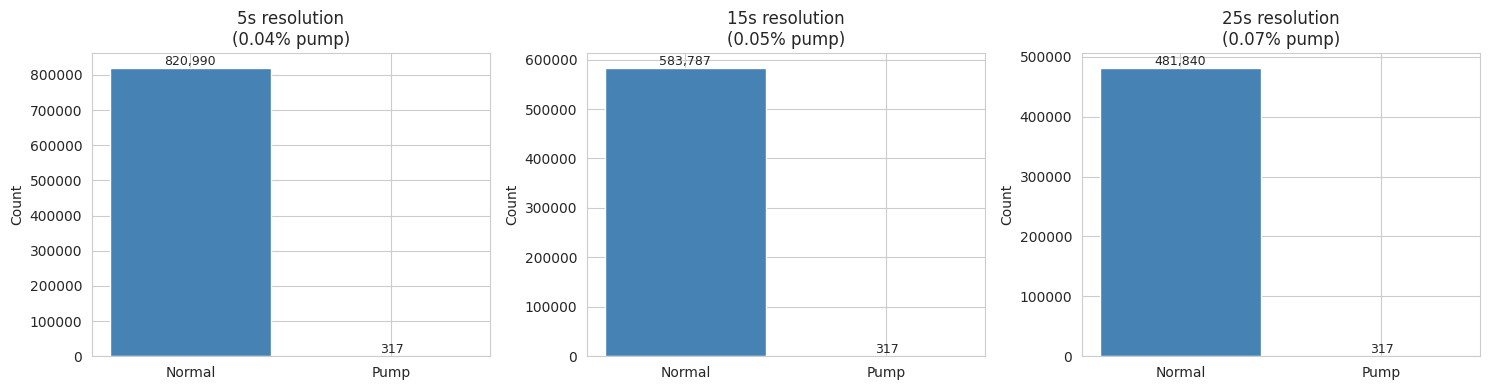

In [ ]:
print("=== Class distribution across all resolutions ===\n")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (name, df) in enumerate(datasets.items()):
    counts = df['gt'].value_counts().sort_index()
    pct = df['gt'].value_counts(normalize=True).sort_index() * 100

    print(f"--- {name} ---")
    print(f"  Normal (0): {counts[0]:>8,} ({pct[0]:.3f}%)")
    print(f"  Pump   (1): {counts[1]:>8,} ({pct[1]:.3f}%)")
    print(f"  Imbalance ratio: 1 : {counts[0]/counts[1]:.0f}")
    print()

    # Plot
    axes[i].bar(['Normal', 'Pump'], counts.values, color=['steelblue', 'crimson'])
    axes[i].set_title(f'{name} resolution\n({pct[1]:.2f}% pump)')
    axes[i].set_ylabel('Count')
    for j, v in enumerate(counts.values):
        axes[i].text(j, v, f'{v:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

## 2.2 Feature Distributions by Class

This section compares the model features for normal rows and pump rows. The goal is not to prove a model yet, but to understand whether the engineered trading, volume, price, and time features show separable behavior that a classifier could reasonably learn from.


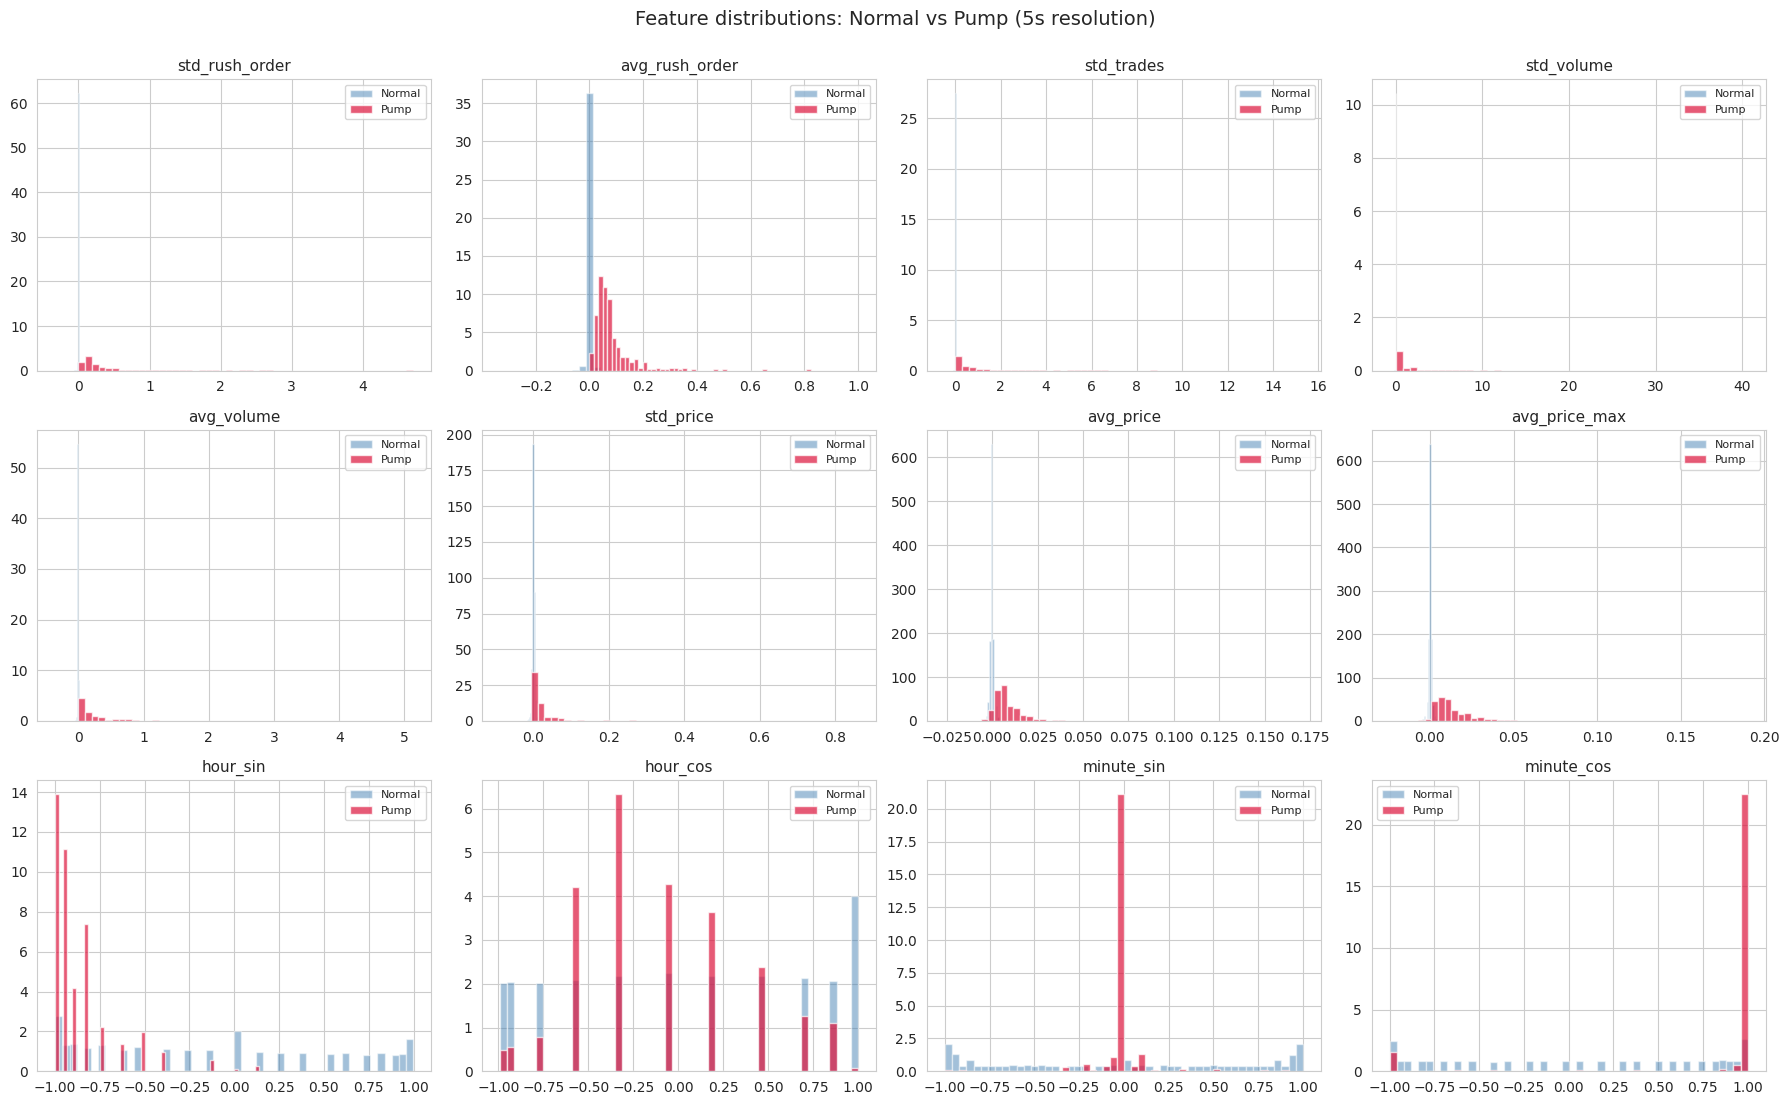


=== Mean of each feature by class (5s) ===
                Normal    Pump  Difference       Ratio
std_rush_order -0.0003  0.3868      0.3871  -1387.2975
avg_rush_order -0.0003  0.0862      0.0865   -282.8598
std_trades     -0.0003  1.2209      1.2212  -4600.0972
std_volume     -0.0001  2.0523      2.0524 -15079.3622
avg_volume     -0.0003  0.3024      0.3027  -1032.6979
std_price      -0.0003  0.0276      0.0279    -92.9318
avg_price      -0.0000  0.0091      0.0091   -806.3504
avg_price_max  -0.0000  0.0146      0.0146  -1633.1838
hour_sin       -0.1208 -0.8598     -0.7390      7.1157
hour_cos        0.0429 -0.1077     -0.1506     -2.5122
minute_sin     -0.0151 -0.0017      0.0134      0.1116
minute_cos      0.0225  0.8567      0.8343     38.1262


In [ ]:
# The 12 features we'll model on
feature_cols = ['std_rush_order', 'avg_rush_order', 'std_trades',
                'std_volume', 'avg_volume', 'std_price', 'avg_price',
                'avg_price_max', 'hour_sin', 'hour_cos', 'minute_sin', 'minute_cos']

# We will use 5s for this since it has the most data.
df = df_5s

fig, axes = plt.subplots(3, 4, figsize=(18, 11))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]

    # Plot normal (subsample for speed — 50K is plenty)
    normal_sample = df[df['gt'] == 0][col].sample(50000, random_state=42)
    pump_values = df[df['gt'] == 1][col]

    ax.hist(normal_sample, bins=50, alpha=0.5, label='Normal', color='steelblue', density=True)
    ax.hist(pump_values, bins=50, alpha=0.7, label='Pump', color='crimson', density=True)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('')
    ax.legend(fontsize=8)

plt.suptitle('Feature distributions: Normal vs Pump (5s resolution)',
             fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=100, bbox_inches='tight')
plt.show()

# Quick numeric summary: mean of each feature per class
print("\n=== Mean of each feature by class (5s) ===")
summary = df.groupby('gt')[feature_cols].mean().T
summary.columns = ['Normal', 'Pump']
summary['Difference'] = summary['Pump'] - summary['Normal']
summary['Ratio'] = summary['Pump'] / summary['Normal'].replace(0, np.nan)
print(summary.round(4))

## 2.3 Feature Correlation Review

The correlation heatmap checks whether groups of features are carrying nearly the same signal. This helps explain model behavior later: tree-based models can tolerate correlated inputs, while simpler models may be more sensitive to redundant or overlapping features.


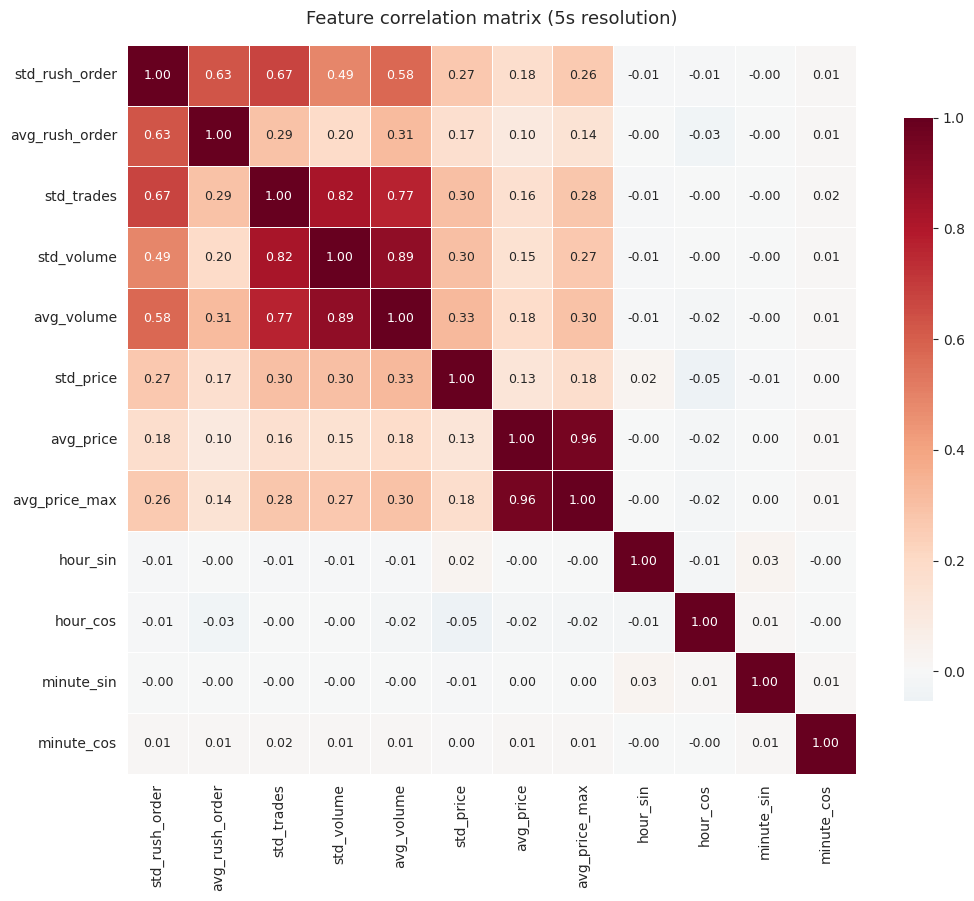


=== Strongly correlated feature pairs (|r| > 0.7) ===
  avg_price          <-> avg_price_max      : r = +0.956
  avg_volume         <-> std_volume         : r = +0.885
  std_volume         <-> std_trades         : r = +0.823
  avg_volume         <-> std_trades         : r = +0.767

=== Each feature's correlation with the target (gt) ===
std_trades        0.4989
std_rush_order    0.4902
avg_volume        0.4203
std_volume        0.4047
avg_price_max     0.2408
avg_rush_order    0.2285
std_price         0.1656
avg_price         0.1613
minute_cos        0.0229
hour_sin         -0.0210
hour_cos         -0.0042
minute_sin        0.0004


In [ ]:
# Correlation among the 12 features
corr = df_5s[feature_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 9}, ax=ax)
ax.set_title('Feature correlation matrix (5s resolution)', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

# Print strongest correlations
print("\n=== Strongly correlated feature pairs (|r| > 0.7) ===")
corr_pairs = corr.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1.0]  # Remove self-correlations
strong = corr_pairs[abs(corr_pairs) > 0.7].drop_duplicates()
if len(strong) > 0:
    for (f1, f2), val in strong.items():
        print(f"  {f1:<18} <-> {f2:<18} : r = {val:+.3f}")
else:
    print("  No pairs with |r| > 0.7 found.")

# Also: correlation with the target
print("\n=== Each feature's correlation with the target (gt) ===")
target_corr = df_5s[feature_cols + ['gt']].corr()['gt'].drop('gt').sort_values(key=abs, ascending=False)
print(target_corr.round(4).to_string())

## 2.4 Time-of-Day Pattern Check

Because market behavior changes over the day, this section looks at the timing of pump activity using the timestamp-derived features. The purpose is to see whether temporal patterns exist without using raw identifiers or future information as model inputs.


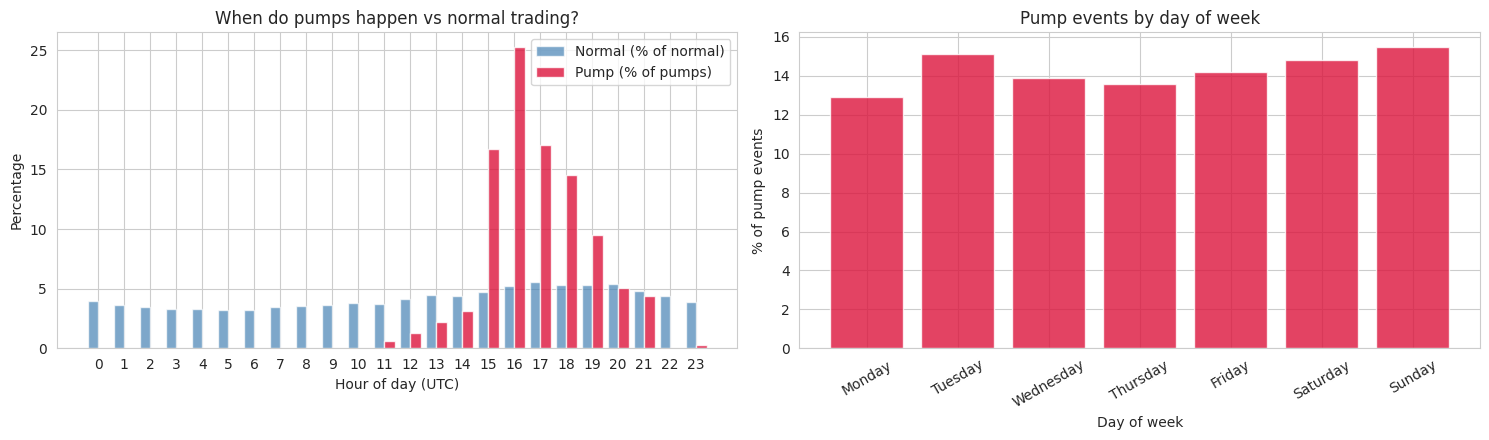

=== Top 5 hours for pump events ===
  Hour 16:00 UTC  ->  80 windows (25.2% of pumps)
  Hour 17:00 UTC  ->  54 windows (17.0% of pumps)
  Hour 15:00 UTC  ->  53 windows (16.7% of pumps)
  Hour 18:00 UTC  ->  46 windows (14.5% of pumps)
  Hour 19:00 UTC  ->  30 windows (9.5% of pumps)

Total pump windows: 317
Number of distinct pump events: 327


In [ ]:
# Convert date to datetime and extract hour
df_5s_copy = df_5s.copy()
df_5s_copy['date'] = pd.to_datetime(df_5s_copy['date'])
df_5s_copy['hour'] = df_5s_copy['date'].dt.hour
df_5s_copy['day_of_week'] = df_5s_copy['date'].dt.day_name()

# --- Hour distribution ---
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

# Pump events by hour
pump_hours = df_5s_copy[df_5s_copy['gt'] == 1]['hour'].value_counts().sort_index()
normal_hours = df_5s_copy[df_5s_copy['gt'] == 0]['hour'].value_counts(normalize=True).sort_index() * 100
pump_hours_pct = (pump_hours / pump_hours.sum()) * 100

x = np.arange(24)
width = 0.4
axes[0].bar(x - width/2, normal_hours.reindex(range(24), fill_value=0), width,
            label='Normal (% of normal)', color='steelblue', alpha=0.7)
axes[0].bar(x + width/2, pump_hours_pct.reindex(range(24), fill_value=0), width,
            label='Pump (% of pumps)', color='crimson', alpha=0.8)
axes[0].set_xlabel('Hour of day (UTC)')
axes[0].set_ylabel('Percentage')
axes[0].set_title('When do pumps happen vs normal trading?')
axes[0].set_xticks(x)
axes[0].legend()

# Day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pump_days = df_5s_copy[df_5s_copy['gt'] == 1]['day_of_week'].value_counts().reindex(day_order)
pump_days_pct = (pump_days / pump_days.sum()) * 100

axes[1].bar(day_order, pump_days_pct.values, color='crimson', alpha=0.8)
axes[1].set_xlabel('Day of week')
axes[1].set_ylabel('% of pump events')
axes[1].set_title('Pump events by day of week')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('pump_timing.png', dpi=100, bbox_inches='tight')
plt.show()

# --- Numeric summary ---
print("=== Top 5 hours for pump events ===")
total_pump_windows = len(df_5s_copy[df_5s_copy['gt'] == 1])
top_hours = df_5s_copy[df_5s_copy['gt'] == 1]['hour'].value_counts().head(5)
for hour, count in top_hours.items():
    pct = count / total_pump_windows * 100
    print(f"  Hour {hour:02d}:00 UTC  ->  {count} windows ({pct:.1f}% of pumps)")

print(f"\nTotal pump windows: {total_pump_windows}")
print(f"Number of distinct pump events: {df_5s_copy['pump_index'].nunique()}")

# Clean up to free memory
del df_5s_copy

# 3. Preprocessing and Split Strategy

This is the main engineering step in the notebook. The pipeline builds feature matrices for each resolution, keeps event groups intact, creates train-fit, validation, and test partitions, and fits scalers only where they are allowed to be fitted. The split design matters because pump-event leakage would make the final scores look better than they really are.


In [ ]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

# Final feature list (12 features)
FEATURE_COLS = [
    'std_rush_order', 'avg_rush_order', 'std_trades',
    'std_volume', 'avg_volume', 'std_price', 'avg_price',
    'avg_price_max', 'hour_sin', 'hour_cos',
    'minute_sin', 'minute_cos'
]

TARGET_COL = 'gt'
GROUP_COL = 'pump_index'


def preprocess_train_val_test(
    df,
    test_size=0.20,
    val_size=0.20,
    random_state=42,
    scale=True,
    verbose=True
):
    missing = sorted(set(FEATURE_COLS + [TARGET_COL, GROUP_COL]) - set(df.columns))
    if missing:
        raise ValueError(f'Missing required columns: {missing}')

    X_raw = df[FEATURE_COLS].values
    y = df[TARGET_COL].values
    groups = df[GROUP_COL].values

    outer = GroupShuffleSplit(
        n_splits=1,
        test_size=test_size,
        random_state=random_state
    )

    train_pool_idx, test_idx = next(outer.split(X_raw, y, groups))

    X_train_pool = X_raw[train_pool_idx]
    y_train_pool = y[train_pool_idx]
    groups_train_pool = groups[train_pool_idx]

    X_test = X_raw[test_idx]
    y_test = y[test_idx]
    groups_test = groups[test_idx]

    inner = GroupShuffleSplit(
        n_splits=1,
        test_size=val_size,
        random_state=random_state + 1
    )

    fit_rel_idx, val_rel_idx = next(
        inner.split(X_train_pool, y_train_pool, groups_train_pool)
    )

    X_fit = X_train_pool[fit_rel_idx]
    y_fit = y_train_pool[fit_rel_idx]
    groups_fit = groups_train_pool[fit_rel_idx]

    X_val = X_train_pool[val_rel_idx]
    y_val = y_train_pool[val_rel_idx]
    groups_val = groups_train_pool[val_rel_idx]

    scaler = None
    if scale:
        scaler = StandardScaler()
        X_fit = scaler.fit_transform(X_fit)
        X_val = scaler.transform(X_val)
        X_test = scaler.transform(X_test)

    fit_events = set(groups_fit)
    val_events = set(groups_val)
    test_events = set(groups_test)

    assert len(fit_events & val_events) == 0, 'Leakage: train_fit/val overlap'
    assert len(fit_events & test_events) == 0, 'Leakage: train_fit/test overlap'
    assert len(val_events & test_events) == 0, 'Leakage: val/test overlap'

    if verbose:
        print(f'Train-fit: {len(X_fit):,} rows | positives={int(y_fit.sum())} | events={len(fit_events)}')
        print(f'Val:       {len(X_val):,} rows | positives={int(y_val.sum())} | events={len(val_events)}')
        print(f'Test:      {len(X_test):,} rows | positives={int(y_test.sum())} | events={len(test_events)}')
        print('No event overlap across train_fit / validation / test.')

    return {
        'X_fit': X_fit,
        'X_val': X_val,
        'X_test': X_test,
        'y_fit': y_fit,
        'y_val': y_val,
        'y_test': y_test,
        'groups_fit': groups_fit,
        'groups_val': groups_val,
        'groups_test': groups_test,
        'scaler': scaler,
        'raw_train_pool_idx': train_pool_idx,
        'raw_test_idx': test_idx,
        'raw_fit_idx': train_pool_idx[fit_rel_idx],
        'raw_val_idx': train_pool_idx[val_rel_idx],
    }


def get_raw_group_rows(resolution, groups):
    """Return raw feature rows, labels, and group IDs for whole event groups."""
    group_set = set(groups)
    df_group = datasets[resolution][datasets[resolution][GROUP_COL].isin(group_set)].reset_index(drop=True)
    return (
        df_group[FEATURE_COLS].values,
        df_group[TARGET_COL].values,
        df_group[GROUP_COL].values,
    )


print('='*70)
print('Building event-disjoint train_fit / validation / test splits')
print('='*70)

splits_clean = {}

splits = {}

for name, df in datasets.items():
    print(f'\n--- {name} resolution ---')
    split = preprocess_train_val_test(
        df,
        test_size=0.20,
        val_size=0.20,
        random_state=42
    )
    splits_clean[name] = split
    splits[name] = (
        split['X_fit'],
        split['X_test'],
        split['y_fit'],
        split['y_test'],
        split['scaler'],
        split['groups_fit'],
        split['groups_test'],
    )

print('\nAll clean splits ready.')

Building event-disjoint train_fit / validation / test splits

--- 5s resolution ---
Train-fit: 518,354 rows | positives=202 | events=208
Val:       132,092 rows | positives=51 | events=53
Test:      170,861 rows | positives=64 | events=66
No event overlap across train_fit / validation / test.

--- 15s resolution ---
Train-fit: 365,936 rows | positives=203 | events=208
Val:       87,442 rows | positives=51 | events=53
Test:      130,726 rows | positives=63 | events=66
No event overlap across train_fit / validation / test.

--- 25s resolution ---
Train-fit: 304,019 rows | positives=203 | events=208
Val:       72,440 rows | positives=51 | events=53
Test:      105,698 rows | positives=63 | events=66
No event overlap across train_fit / validation / test.

All clean splits ready.


## 3.1 Split Validation and Reproducibility Check

After creating the clean splits, this section verifies that the resulting train-fit, validation, and test sets have the expected sizes and class distributions. It also confirms that event groups are separated properly, which protects the evaluation from seeing the same pump event in multiple phases.


In [ ]:
print('='*70)
print('Split checking for the train_fit/validation/test split')
print('='*70)

split_5s = splits_clean['5s']
X_tr = split_5s['X_fit']
X_val = split_5s['X_val']
X_te = split_5s['X_test']
y_tr = split_5s['y_fit']
y_val = split_5s['y_val']
y_te = split_5s['y_test']
train_grp = split_5s['groups_fit']
val_grp = split_5s['groups_val']
test_grp = split_5s['groups_test']

train_event_ids = set(train_grp)
val_event_ids = set(val_grp)
test_event_ids = set(test_grp)

assert len(train_event_ids & val_event_ids) == 0
assert len(train_event_ids & test_event_ids) == 0
assert len(val_event_ids & test_event_ids) == 0

# 1. Are pump events temporally represented across all partitions?
df = df_5s.copy()
df['date'] = pd.to_datetime(df['date'])


def date_range_text(series):
    if len(series) == 0:
        return 'no positive rows'
    return f'{series.min().date()} -> {series.max().date()}'

train_dates = df[df['pump_index'].isin(train_event_ids) & (df['gt'] == 1)]['date']
val_dates = df[df['pump_index'].isin(val_event_ids) & (df['gt'] == 1)]['date']
test_dates = df[df['pump_index'].isin(test_event_ids) & (df['gt'] == 1)]['date']

print('\n--- Temporal distribution of pump events ---')
print(f'Train-fit pumps: {date_range_text(train_dates)}')
print(f'Validation pumps: {date_range_text(val_dates)}')
print(f'Test pumps: {date_range_text(test_dates)}')

# 2. Do test pumps span multiple coins? (avoid one-coin overfitting)
test_coins = df[df['pump_index'].isin(test_event_ids) & (df['gt'] == 1)]['symbol'].unique()
train_coins = df[df['pump_index'].isin(train_event_ids) & (df['gt'] == 1)]['symbol'].unique()
val_coins = df[df['pump_index'].isin(val_event_ids) & (df['gt'] == 1)]['symbol'].unique()

print('\n--- Coin diversity ---')
print(f'Train-fit: {len(train_coins)} unique coins with pumps')
print(f'Validation: {len(val_coins)} unique coins with pumps')
print(f'Test:      {len(test_coins)} unique coins with pumps')
print(f'Train/test coin overlap: {len(set(train_coins) & set(test_coins))}')

# 3. Confirm scaling worked correctly. Scaler is fit only on train_fit.
print('\n--- Feature scaling check (5s) ---')
print(f'X_train_fit mean (should be ~0): {X_tr.mean():.4f}')
print(f'X_train_fit std  (should be ~1): {X_tr.std():.4f}')
print(f'X_val mean (small but nonzero):  {X_val.mean():.4f}')
print(f'X_test mean (small but nonzero): {X_te.mean():.4f}')

# 4. Test pump events - show the breakdown
print('\n--- Test set pump events: hour distribution ---')
test_pump_rows = df[df['pump_index'].isin(test_event_ids) & (df['gt'] == 1)]
hour_dist = test_pump_rows['date'].dt.hour.value_counts().sort_index()
print(hour_dist.to_string())

Split checking for the train_fit/validation/test split

--- Temporal distribution of pump events ---
Train-fit pumps: 2018-01-03 -> 2021-01-18
Validation pumps: 2018-01-23 -> 2021-01-07
Test pumps: 2018-01-09 -> 2021-01-13

--- Coin diversity ---
Train-fit: 67 unique coins with pumps
Validation: 38 unique coins with pumps
Test:      46 unique coins with pumps
Train/test coin overlap: 31

--- Feature scaling check (5s) ---
X_train_fit mean (should be ~0): 0.0000
X_train_fit std  (should be ~1): 1.0000
X_val mean (small but nonzero):  -0.0000
X_test mean (small but nonzero): -0.0029

--- Test set pump events: hour distribution ---
date
12     3
14     3
15    13
16    12
17     8
18    15
19     5
20     3
21     2


## 3.2 Feature Leakage Audit

This audit explicitly checks that labels, timestamps, symbols, and event identifiers are not being used as model features. It also reports suspicious feature relationships so any unusually strong signal can be reviewed before trusting downstream model performance.


In [ ]:
print('=' * 70)
print('Feature-leakage audit')
print('=' * 70)

excluded_cols = {'date', 'symbol', GROUP_COL, TARGET_COL}
illegal_features = sorted(set(FEATURE_COLS) & excluded_cols)
if illegal_features:
    raise ValueError(f'Leakage-risk columns included as model features: {illegal_features}')
print(f'Features used by models: {len(FEATURE_COLS)}')
print(f'Excluded identifier/label columns: {sorted(excluded_cols)}')

precomputed_feature_audit = {}
for resolution, df in datasets.items():
    missing = sorted(set(FEATURE_COLS) - set(df.columns))
    extra_nulls = int(df[FEATURE_COLS].isnull().sum().sum())
    pos_groups = int((df.groupby(GROUP_COL)[TARGET_COL].sum() > 0).sum())
    zero_pos_groups = int((df.groupby(GROUP_COL)[TARGET_COL].sum() == 0).sum())
    negative_std_counts = {
        col: int((df[col] < 0).sum())
        for col in FEATURE_COLS
        if col.startswith('std_')
    }
    per_event_zscore_signature = {}
    for col in ['std_rush_order', 'std_volume']:
        per_event_mean = df.groupby(GROUP_COL)[col].mean()
        per_event_std = df.groupby(GROUP_COL)[col].std()
        per_event_zscore_signature[col] = {
            'median_abs_event_mean': float(per_event_mean.abs().median()),
            'median_event_std': float(per_event_std.median()),
            'frac_event_mean_below_1e_4': float((per_event_mean.abs() < 1e-4).mean()),
            'frac_event_std_in_unit_band': float(((per_event_std > 0.95) & (per_event_std < 1.05)).mean()),
        }

    precomputed_feature_audit[resolution] = {
        'missing_feature_columns': missing,
        'feature_null_count': extra_nulls,
        'groups_with_positive_rows': pos_groups,
        'groups_without_positive_rows': zero_pos_groups,
        'negative_std_counts': negative_std_counts,
        'per_event_zscore_signature': per_event_zscore_signature,
    }

    print(f'\n--- {resolution} ---')
    print(f'Rows: {len(df):,} | Groups: {df[GROUP_COL].nunique()} | Pump rows: {int(df[TARGET_COL].sum())}')
    print(f'Missing feature columns: {missing if missing else "none"}')
    print(f'Feature null count: {extra_nulls}')
    print(f'Groups with/without positive rows: {pos_groups}/{zero_pos_groups}')
    print(f'Negative values in std_* columns: {negative_std_counts}')
    print('Per-event z-score probe (would indicate leakage if mean≈0 AND std≈1):')
    for col, sig in per_event_zscore_signature.items():
        print(f'  {col}: median |mean|={sig["median_abs_event_mean"]:.5f} '
              f'median std={sig["median_event_std"]:.4f} '
              f'frac(std≈1)={sig["frac_event_std_in_unit_band"]:.2%}')
print('\n--- Coin overlap across train_fit / val / test (25s) ---')
df_25 = datasets['25s']
fit_events = set(splits_clean['25s']['groups_fit'])
val_events = set(splits_clean['25s']['groups_val'])
test_events = set(splits_clean['25s']['groups_test'])

fit_coins = set(df_25[df_25[GROUP_COL].isin(fit_events)]['symbol'].unique())
val_coins = set(df_25[df_25[GROUP_COL].isin(val_events)]['symbol'].unique())
test_coins = set(df_25[df_25[GROUP_COL].isin(test_events)]['symbol'].unique())
print(f'  Fit coins:  {len(fit_coins):>3}')
print(f'  Val coins:  {len(val_coins):>3}  | overlap with fit: {len(val_coins & fit_coins)}')
print(f'  Test coins: {len(test_coins):>3} | overlap with fit: {len(test_coins & fit_coins)} | overlap with val: {len(test_coins & val_coins)}')

df_25 = df_25.copy()
df_25['date_parsed'] = pd.to_datetime(df_25['date'])
events_with_pump = df_25[df_25[TARGET_COL] == 1][GROUP_COL].unique()
pre_pump_rows = []
for ev in events_with_pump[:200]:  # cap for speed
    ev_rows = df_25[df_25[GROUP_COL] == ev].sort_values('date_parsed')
    pump_pos = ev_rows[ev_rows[TARGET_COL] == 1].index
    if len(pump_pos) == 0:
        continue
    first_pump = pump_pos[0]
    prev_idx = ev_rows.index[ev_rows.index.get_loc(first_pump) - 1] if ev_rows.index.get_loc(first_pump) > 0 else None
    if prev_idx is not None:
        pre_pump_rows.append(ev_rows.loc[prev_idx])

if pre_pump_rows:
    pre_pump_df = pd.DataFrame(pre_pump_rows)
    pump_df = df_25[df_25[TARGET_COL] == 1]
    nonpump_df = df_25[df_25[TARGET_COL] == 0]
    print('\n--- Pre-pump row signature (the window IMMEDIATELY before the pump in 25s) ---')
    cmp = pd.DataFrame({
        'mean(non-pump)': nonpump_df[FEATURE_COLS].mean(),
        'mean(pre-pump row)': pre_pump_df[FEATURE_COLS].mean(),
        'mean(pump row)': pump_df[FEATURE_COLS].mean(),
    }).round(4)
    print(cmp.to_string())

Feature-leakage audit
Features used by models: 12
Excluded identifier/label columns: ['date', 'gt', 'pump_index', 'symbol']

--- 5s ---
Rows: 821,307 | Groups: 327 | Pump rows: 317
Missing feature columns: none
Feature null count: 0
Groups with/without positive rows: 317/10
Negative values in std_* columns: {'std_rush_order': 113526, 'std_trades': 95298, 'std_volume': 66113, 'std_price': 337902}
Per-event z-score probe (would indicate leakage if mean≈0 AND std≈1):
  std_rush_order: median |mean|=0.00023 median std=0.0085 frac(std≈1)=0.00%
  std_volume: median |mean|=0.00046 median std=0.0273 frac(std≈1)=0.00%

--- 15s ---
Rows: 584,104 | Groups: 327 | Pump rows: 317
Missing feature columns: none
Feature null count: 0
Groups with/without positive rows: 317/10
Negative values in std_* columns: {'std_rush_order': 60258, 'std_trades': 50377, 'std_volume': 38258, 'std_price': 205818}
Per-event z-score probe (would indicate leakage if mean≈0 AND std≈1):
  std_rush_order: median |mean|=0.0003

## 3.3 Imbalance Handling Setup

The dataset is highly imbalanced, so the notebook prepares two controlled strategies: class weighting and SMOTE. Both are applied only to training data, leaving validation and test data untouched so the reported metrics reflect the real class distribution.


In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.utils.class_weight import compute_class_weight


def apply_smote(X_train, y_train, random_state=42, verbose=True):
    """Apply SMOTE to the train_fit set only."""
    if verbose:
        print(f'  Before SMOTE: {Counter(y_train)}')
    n_minority = (y_train == 1).sum()
    k = min(5, n_minority - 1)
    smote = SMOTE(random_state=random_state, k_neighbors=k)
    X_res, y_res = smote.fit_resample(X_train, y_train)
    if verbose:
        print(f'  After SMOTE:  {Counter(y_res)}')
        print(f'  New shape:    {X_res.shape}')
    return X_res, y_res


def get_class_weights(y_train, verbose=True):
    classes = np.array([0, 1])
    weights = compute_class_weight('balanced', classes=classes, y=y_train)
    weight_dict = {0: weights[0], 1: weights[1]}
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    if verbose:
        print(f'  Class weights:    {weight_dict}')
        print(f'  scale_pos_weight: {scale_pos_weight:.1f}  (for XGBoost)')
    return weight_dict, scale_pos_weight


print('=' * 70)
print('Pre-computing class weights for all resolutions (train_fit only)')
print('=' * 70)

class_weights_all = {}
scale_pos_all = {}
for name in ['5s', '15s', '25s']:
    print(f'\n--- {name} ---')
    y_fit = splits_clean[name]['y_fit']
    cw, sp = get_class_weights(y_fit)
    class_weights_all[name] = cw
    scale_pos_all[name] = sp


Pre-computing class weights for all resolutions (train_fit only)

--- 5s ---
  Class weights:    {0: np.float64(0.5001949234973522), 1: np.float64(1283.0544554455446)}
  scale_pos_weight: 2565.1  (for XGBoost)

--- 15s ---
  Class weights:    {0: np.float64(0.5002775248610325), 1: np.float64(901.320197044335)}
  scale_pos_weight: 1801.6  (for XGBoost)

--- 25s ---
  Class weights:    {0: np.float64(0.5003340837875556), 1: np.float64(748.8152709359606)}
  scale_pos_weight: 1496.6  (for XGBoost)


# 4. Unified Evaluation Framework

All models are evaluated through the same metric function. This keeps precision, recall, F1, PR-AUC, ROC-AUC, confusion matrices, timing, thresholds, and result logging consistent across algorithms and resolutions. Using one evaluation path also makes the final comparison easier to audit.


In [ ]:
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score,
                             confusion_matrix, precision_recall_curve,
                             roc_curve)
import time

results_log = []


def evaluate_model(model, X_eval, y_eval, model_name, resolution,
                   imbalance_strategy, train_time=None,
                   threshold=0.5, store=True, verbose=True,
                   evaluation_set='val'):
    if evaluation_set not in ('val', 'test'):
        raise ValueError("evaluation_set must be 'val' or 'test'")

    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_eval)[:, 1]
    elif hasattr(model, 'decision_function'):
        scores = model.decision_function(X_eval)
        y_proba = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
    else:
        y_proba = model.predict(X_eval).astype(float)
        if y_proba.ndim > 1:
            y_proba = y_proba.ravel()

    y_pred = (y_proba >= threshold).astype(int)

    cm = confusion_matrix(y_eval, y_pred)
    tn, fp, fn, tp = cm.ravel()

    metrics = {
        'model': model_name,
        'resolution': resolution,
        'imbalance': imbalance_strategy,
        'evaluation_set': evaluation_set,
        'precision': precision_score(y_eval, y_pred, zero_division=0),
        'recall':    recall_score(y_eval, y_pred, zero_division=0),
        'f1':        f1_score(y_eval, y_pred, zero_division=0),
        'roc_auc':   roc_auc_score(y_eval, y_proba),
        'pr_auc':    average_precision_score(y_eval, y_proba),
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
        'threshold': threshold,
        'train_time_s': round(train_time, 2) if train_time else None,
    }

    if store:
        results_log.append(metrics)

    if verbose:
        tag = 'TEST' if evaluation_set == 'test' else 'val'
        print(f"\n  {model_name} | {resolution} | {imbalance_strategy} | [{tag}]")
        print(f"  ├─ Precision: {metrics['precision']:.4f}")
        print(f"  ├─ Recall:    {metrics['recall']:.4f}")
        print(f"  ├─ F1:        {metrics['f1']:.4f}")
        print(f"  ├─ ROC-AUC:   {metrics['roc_auc']:.4f}")
        print(f"  ├─ PR-AUC:    {metrics['pr_auc']:.4f}")
        print(f"  └─ Confusion: TP={metrics['tp']}  FP={metrics['fp']}  "
              f"FN={metrics['fn']}  TN={metrics['tn']:,}")

    return metrics


def show_results_table(top_n=None, sort_by='f1', evaluation_set=None):
    """Display the master results table; optionally filter by evaluation_set."""
    if not results_log:
        print('No results logged yet.')
        return None
    df_r = pd.DataFrame(results_log)
    if evaluation_set is not None:
        df_r = df_r[df_r['evaluation_set'] == evaluation_set]
    df_r = df_r.sort_values(sort_by, ascending=False)
    cols = ['model', 'resolution', 'imbalance', 'evaluation_set',
            'precision', 'recall', 'f1', 'pr_auc', 'roc_auc',
            'tp', 'fp', 'fn', 'threshold', 'train_time_s']
    if top_n:
        df_r = df_r.head(top_n)
    print(df_r[cols].to_string(index=False))
    return df_r


print('Evaluation framework ready.')

Evaluation framework ready.


# 5. Model Training

## 5.1 Baseline Model: Gaussian Naive Bayes

Naive Bayes is used as a lightweight baseline. It is not expected to be the strongest model, but it gives a useful reference point for how much value the more flexible models add beyond a simple probabilistic classifier.


In [ ]:
from sklearn.naive_bayes import GaussianNB

print('=' * 70)
print('MODEL 1: Naive Bayes (GaussianNB)')
print('=' * 70)


def get_priors_from_weights(class_weight_dict):
    total = class_weight_dict[0] + class_weight_dict[1]
    return [class_weight_dict[0] / total, class_weight_dict[1] / total]


nb_models = {}

for resolution in ['5s', '15s', '25s']:
    print(f"\n{'─' * 60}\n  Resolution: {resolution}\n{'─' * 60}")
    sp = splits_clean[resolution]
    X_fit, y_fit = sp['X_fit'], sp['y_fit']
    X_val, y_val = sp['X_val'], sp['y_val']

    # ---------- Strategy A: SMOTE ----------
    print('\n  [Strategy A: SMOTE]')
    X_smote, y_smote = apply_smote(X_fit, y_fit, verbose=False)
    t0 = time.time()
    nb_smote = GaussianNB()
    nb_smote.fit(X_smote, y_smote)
    train_time = time.time() - t0
    evaluate_model(nb_smote, X_val, y_val,
                   model_name='Naive Bayes', resolution=resolution,
                   imbalance_strategy='SMOTE', train_time=train_time,
                   evaluation_set='val')
    nb_models[f'NB_{resolution}_SMOTE'] = nb_smote

    # ---------- Strategy B: class-weight priors ----------
    print('\n  [Strategy B: Class weights (priors)]')
    priors = get_priors_from_weights(class_weights_all[resolution])
    t0 = time.time()
    nb_weighted = GaussianNB(priors=priors)
    nb_weighted.fit(X_fit, y_fit)
    train_time = time.time() - t0
    evaluate_model(nb_weighted, X_val, y_val,
                   model_name='Naive Bayes', resolution=resolution,
                   imbalance_strategy='class_weight', train_time=train_time,
                   evaluation_set='val')
    nb_models[f'NB_{resolution}_weighted'] = nb_weighted

    del X_smote, y_smote

print('\n' + '=' * 70)
print('Naive Bayes - 6 validation experiments complete')
print('=' * 70)
nb_results = pd.DataFrame([r for r in results_log
                           if r['model'] == 'Naive Bayes' and r['evaluation_set'] == 'val'])
nb_results = nb_results.sort_values('f1', ascending=False)
print(nb_results[['resolution', 'imbalance', 'precision', 'recall',
                  'f1', 'pr_auc', 'tp', 'fp']].to_string(index=False))
print(f"\nTotal validation rows in results_log: {sum(1 for r in results_log if r['evaluation_set'] == 'val')}")


MODEL 1: Naive Bayes (GaussianNB)

────────────────────────────────────────────────────────────
  Resolution: 5s
────────────────────────────────────────────────────────────

  [Strategy A: SMOTE]

  Naive Bayes | 5s | SMOTE | [val]
  ├─ Precision: 0.0709
  ├─ Recall:    0.9804
  ├─ F1:        0.1323
  ├─ ROC-AUC:   0.9983
  ├─ PR-AUC:    0.1068
  └─ Confusion: TP=50  FP=655  FN=1  TN=131,386

  [Strategy B: Class weights (priors)]

  Naive Bayes | 5s | class_weight | [val]
  ├─ Precision: 0.0491
  ├─ Recall:    0.9804
  ├─ F1:        0.0935
  ├─ ROC-AUC:   0.9979
  ├─ PR-AUC:    0.0878
  └─ Confusion: TP=50  FP=968  FN=1  TN=131,073

────────────────────────────────────────────────────────────
  Resolution: 15s
────────────────────────────────────────────────────────────

  [Strategy A: SMOTE]

  Naive Bayes | 15s | SMOTE | [val]
  ├─ Precision: 0.1192
  ├─ Recall:    1.0000
  ├─ F1:        0.2129
  ├─ ROC-AUC:   0.9983
  ├─ PR-AUC:    0.1468
  └─ Confusion: TP=51  FP=377  FN=0  TN=87

## 5.2 Random Forest

Random Forest is the main classical tree-based model in the notebook. It handles nonlinear feature interactions well, supports class weighting, and gives a strong practical benchmark for this kind of tabular detection problem.


MODEL 2: Random Forest

────────────────────────────────────────────────────────────
  Resolution: 5s
────────────────────────────────────────────────────────────

  [class_weight='balanced']
  (trained in 13.8s)

  Random Forest | 5s | class_weight | [val]
  ├─ Precision: 0.7719
  ├─ Recall:    0.8627
  ├─ F1:        0.8148
  ├─ ROC-AUC:   0.9999
  ├─ PR-AUC:    0.9015
  └─ Confusion: TP=44  FP=13  FN=7  TN=132,028
  Train F1=0.8958 | Val F1=0.8148 | Gap=+0.0810

────────────────────────────────────────────────────────────
  Resolution: 15s
────────────────────────────────────────────────────────────

  [class_weight='balanced']
  (trained in 10.0s)

  Random Forest | 15s | class_weight | [val]
  ├─ Precision: 0.9000
  ├─ Recall:    0.8824
  ├─ F1:        0.8911
  ├─ ROC-AUC:   1.0000
  ├─ PR-AUC:    0.9575
  └─ Confusion: TP=45  FP=5  FN=6  TN=87,386
  Train F1=0.9333 | Val F1=0.8911 | Gap=+0.0422

────────────────────────────────────────────────────────────
  Resolution: 25s
───────

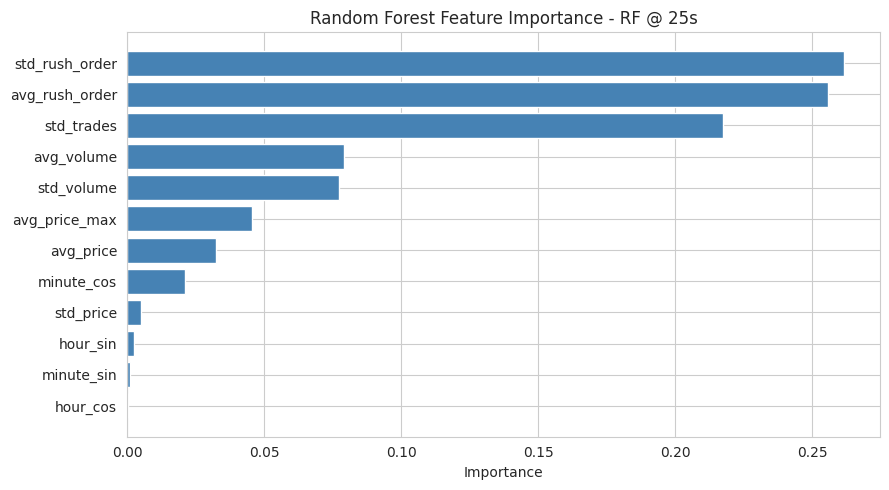


--- Train/Val gap (overfitting probe) ---
  5s: fit_F1=0.8958  val_F1=0.8148  gap=+0.0810
  15s: fit_F1=0.9333  val_F1=0.8911  gap=+0.0422
  25s: fit_F1=0.9713  val_F1=0.8932  gap=+0.0781


In [ ]:
from sklearn.ensemble import RandomForestClassifier

print('=' * 70)
print('MODEL 2: Random Forest')
print('=' * 70)

RF_PARAMS = {
    'n_estimators': 100,
    'max_depth': 15,
    'min_samples_leaf': 5,
    'n_jobs': -1,
    'random_state': 42,
}

rf_models = {}
rf_train_times_clean = {}
rf_train_val_gap = {}

for resolution in ['5s', '15s', '25s']:
    print(f"\n{'─' * 60}\n  Resolution: {resolution}\n{'─' * 60}")
    sp = splits_clean[resolution]
    X_fit, y_fit = sp['X_fit'], sp['y_fit']
    X_val, y_val = sp['X_val'], sp['y_val']

    print("\n  [class_weight='balanced']")
    t0 = time.time()
    rf_weighted = RandomForestClassifier(
        **RF_PARAMS,
        class_weight=class_weights_all[resolution]
    )
    rf_weighted.fit(X_fit, y_fit)
    train_time = time.time() - t0
    print(f'  (trained in {train_time:.1f}s)')

    # Train-vs-val overfitting probe
    fit_proba = rf_weighted.predict_proba(X_fit)[:, 1]
    fit_pred = (fit_proba >= 0.5).astype(int)
    fit_f1 = f1_score(y_fit, fit_pred, zero_division=0)
    fit_pr_auc = average_precision_score(y_fit, fit_proba)

    evaluate_model(rf_weighted, X_val, y_val,
                   model_name='Random Forest', resolution=resolution,
                   imbalance_strategy='class_weight', train_time=train_time,
                   evaluation_set='val')

    val_row = next(r for r in reversed(results_log)
                   if r['model'] == 'Random Forest' and r['resolution'] == resolution
                   and r['evaluation_set'] == 'val')
    gap = fit_f1 - val_row['f1']
    rf_train_val_gap[resolution] = {
        'fit_f1': fit_f1, 'val_f1': val_row['f1'], 'gap': gap,
        'fit_pr_auc': fit_pr_auc, 'val_pr_auc': val_row['pr_auc'],
    }
    print(f'  Train F1={fit_f1:.4f} | Val F1={val_row["f1"]:.4f} | Gap={gap:+.4f}')

    rf_models[f'RF_{resolution}_weighted'] = rf_weighted
    rf_train_times_clean[resolution] = train_time

print('\n' + '=' * 70)
print('Random Forest - validation experiments complete')
print('=' * 70)

rf_results = pd.DataFrame([r for r in results_log
                           if r['model'] == 'Random Forest' and r['evaluation_set'] == 'val'])
rf_results = rf_results.sort_values('f1', ascending=False)
print(rf_results[['resolution', 'imbalance', 'precision', 'recall',
                  'f1', 'pr_auc', 'tp', 'fp', 'train_time_s']].to_string(index=False))

best_rf_res = rf_results.iloc[0]['resolution']
best_rf = rf_models[f'RF_{best_rf_res}_weighted']
print(f'\n--- Feature importance from RF @ {best_rf_res} (best val F1) ---')
fi = pd.DataFrame({'feature': FEATURE_COLS,
                   'importance': best_rf.feature_importances_}).sort_values('importance', ascending=False)
print(fi.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(fi['feature'][::-1], fi['importance'][::-1], color='steelblue')
ax.set_xlabel('Importance')
ax.set_title(f'Random Forest Feature Importance - RF @ {best_rf_res}')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

print('\n--- Train/Val gap (overfitting probe) ---')
for res, g in rf_train_val_gap.items():
    print(f'  {res}: fit_F1={g["fit_f1"]:.4f}  val_F1={g["val_f1"]:.4f}  gap={g["gap"]:+.4f}')


## 5.3 Random Forest Cross-Validation

This section runs grouped cross-validation on the training side only. The purpose is to check whether Random Forest performance is stable across event groups instead of depending on one lucky train-validation split.


In [ ]:
from sklearn.model_selection import GroupKFold

print('=' * 70)
print('ROBUSTNESS CHECK: 5-fold GroupKFold CV on train_fit only')
print('=' * 70)


clean_cv_results = {}

for resolution in ['5s', '15s', '25s']:
    print(f"\n{'-' * 60}\n  Resolution: {resolution}\n{'-' * 60}")
    sp = splits_clean[resolution]
    train_event_set = set(sp['groups_fit'])
    val_event_set = set(sp['groups_val'])
    test_event_set = set(sp['groups_test'])
    df_full = datasets[resolution]
    df_train_only = df_full[df_full[GROUP_COL].isin(train_event_set)].reset_index(drop=True)
    X_tr_only = df_train_only[FEATURE_COLS].values
    y_tr_only = df_train_only[TARGET_COL].values
    g_tr_only = df_train_only[GROUP_COL].values

    assert len(set(g_tr_only) & val_event_set) == 0
    assert len(set(g_tr_only) & test_event_set) == 0
    print(f'  CV pool: {len(X_tr_only):,} rows | {len(set(g_tr_only))} events | {int(y_tr_only.sum())} pumps')

    gkf = GroupKFold(n_splits=5)
    fold_metrics = {'f1': [], 'precision': [], 'recall': [], 'pr_auc': []}

    for fold_idx, (tr_idx, va_idx) in enumerate(gkf.split(X_tr_only, y_tr_only, g_tr_only)):
        X_tr_cv, X_va_cv = X_tr_only[tr_idx], X_tr_only[va_idx]
        y_tr_cv, y_va_cv = y_tr_only[tr_idx], y_tr_only[va_idx]

        scaler_cv = StandardScaler()
        X_tr_cv = scaler_cv.fit_transform(X_tr_cv)
        X_va_cv = scaler_cv.transform(X_va_cv)
        cw_fold, _ = get_class_weights(y_tr_cv, verbose=False)

        rf_cv = RandomForestClassifier(
            n_estimators=100, max_depth=15, min_samples_leaf=5,
            class_weight=cw_fold, n_jobs=-1, random_state=42,
        )
        rf_cv.fit(X_tr_cv, y_tr_cv)
        y_proba = rf_cv.predict_proba(X_va_cv)[:, 1]
        y_pred = (y_proba >= 0.5).astype(int)
        fold_metrics['f1'].append(f1_score(y_va_cv, y_pred, zero_division=0))
        fold_metrics['precision'].append(precision_score(y_va_cv, y_pred, zero_division=0))
        fold_metrics['recall'].append(recall_score(y_va_cv, y_pred, zero_division=0))
        fold_metrics['pr_auc'].append(average_precision_score(y_va_cv, y_proba))
        print(f"  Fold {fold_idx + 1}: F1={fold_metrics['f1'][-1]:.4f}  "
              f"P={fold_metrics['precision'][-1]:.3f}  "
              f"R={fold_metrics['recall'][-1]:.3f}  "
              f"PR-AUC={fold_metrics['pr_auc'][-1]:.3f}")

    clean_cv_results[resolution] = {
        m: {'mean': float(np.mean(v)), 'std': float(np.std(v)),
            'min': float(np.min(v)), 'max': float(np.max(v))}
        for m, v in fold_metrics.items()
    }
    print(f"\n  CV summary ({resolution}):")
    for m in ['f1', 'precision', 'recall', 'pr_auc']:
        s = clean_cv_results[resolution][m]
        print(f"    {m:>9}: {s['mean']:.4f} +/- {s['std']:.4f}")

# ---------- Compare CV F1 vs single-split val F1 (both are training-side numbers) ----------
print('\n' + '=' * 70)
print('CV vs single-split validation F1')
print('=' * 70)
print(f"{'Resolution':<12}{'CV F1 (train-only)':<26}{'Val F1 (single split)':<24}{'Status':<22}")
print('-' * 84)

publishable = True
cv_vs_val = {}
for res in ['5s', '15s', '25s']:
    cv_mean = clean_cv_results[res]['f1']['mean']
    cv_std = clean_cv_results[res]['f1']['std']
    val_rows = [r for r in results_log
                if r['model'] == 'Random Forest' and r['resolution'] == res
                and r['evaluation_set'] == 'val' and r['imbalance'] == 'class_weight'
                and abs(r['threshold'] - 0.5) < 1e-9]
    val_f1 = val_rows[0]['f1'] if val_rows else float('nan')
    diff = abs(cv_mean - val_f1)
    cv_vs_val[res] = {'cv_mean': cv_mean, 'cv_std': cv_std, 'val_f1': val_f1, 'abs_diff': diff}
    if diff <= cv_std:
        status = 'within 1 std'
    elif diff <= 2 * cv_std:
        status = 'within 2 std'
    else:
        status = '>2 std apart'
        publishable = False
    print(f'{res:<12}{cv_mean:.4f} +/- {cv_std:.4f}        {val_f1:.4f}                  {status}')

ROBUSTNESS CHECK: 5-fold GroupKFold CV on train_fit only

------------------------------------------------------------
  Resolution: 5s
------------------------------------------------------------
  CV pool: 518,354 rows | 208 events | 202 pumps
  Fold 1: F1=0.9231  P=0.947  R=0.900  PR-AUC=0.984
  Fold 2: F1=0.7579  P=0.667  R=0.878  PR-AUC=0.875
  Fold 3: F1=0.8434  P=0.814  R=0.875  PR-AUC=0.899
  Fold 4: F1=0.8276  P=0.766  R=0.900  PR-AUC=0.901
  Fold 5: F1=0.7742  P=0.692  R=0.878  PR-AUC=0.848

  CV summary (5s):
           f1: 0.8252 +/- 0.0584
    precision: 0.7773 +/- 0.0999
       recall: 0.8862 +/- 0.0113
       pr_auc: 0.9015 +/- 0.0455

------------------------------------------------------------
  Resolution: 15s
------------------------------------------------------------
  CV pool: 365,936 rows | 208 events | 203 pumps
  Fold 1: F1=0.8642  P=0.875  R=0.854  PR-AUC=0.936
  Fold 2: F1=0.8632  P=0.759  R=1.000  PR-AUC=0.989
  Fold 3: F1=0.9024  P=0.902  R=0.902  PR-AUC=0.

## 5.4 XGBoost

XGBoost is included as a stronger gradient-boosted tree model. It is trained with imbalance-aware settings and validation monitoring, giving the notebook a high-capacity tabular model to compare against Random Forest and the neural network.


MODEL 3: XGBoost

────────────────────────────────────────────────────────────
  Resolution: 5s
────────────────────────────────────────────────────────────

  [scale_pos_weight=2565]
  (trained in 5.4s, best_iter=104)

  XGBoost | 5s | class_weight | [val]
  ├─ Precision: 0.4894
  ├─ Recall:    0.9020
  ├─ F1:        0.6345
  ├─ ROC-AUC:   0.9999
  ├─ PR-AUC:    0.8126
  └─ Confusion: TP=46  FP=48  FN=5  TN=131,993
  Train F1=0.7426 | Val F1=0.6345 | Gap=+0.1082

────────────────────────────────────────────────────────────
  Resolution: 15s
────────────────────────────────────────────────────────────

  [scale_pos_weight=1802]
  (trained in 4.5s, best_iter=67)

  XGBoost | 15s | class_weight | [val]
  ├─ Precision: 0.6173
  ├─ Recall:    0.9804
  ├─ F1:        0.7576
  ├─ ROC-AUC:   0.9999
  ├─ PR-AUC:    0.9334
  └─ Confusion: TP=50  FP=31  FN=1  TN=87,360
  Train F1=0.7409 | Val F1=0.7576 | Gap=-0.0167

────────────────────────────────────────────────────────────
  Resolution: 25s
─

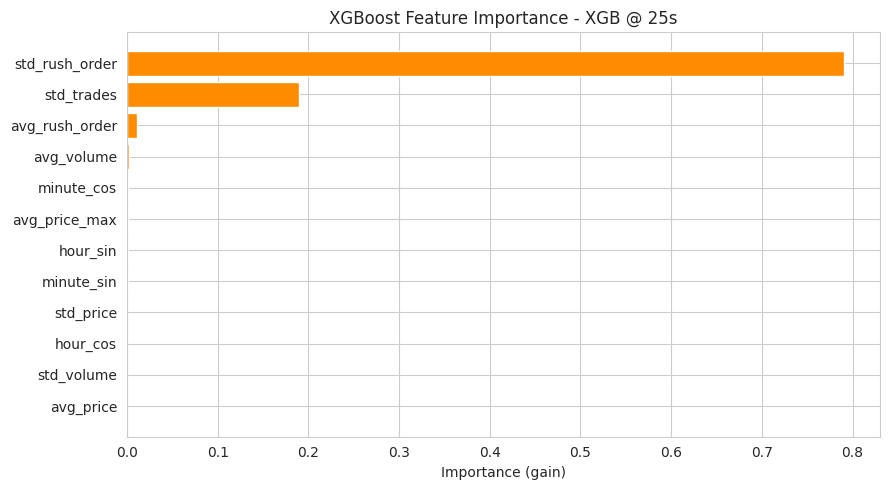


--- Train/Val gap (overfitting probe) ---
  5s: fit_F1=0.7426  val_F1=0.6345  gap=+0.1082
  15s: fit_F1=0.7409  val_F1=0.7576  gap=-0.0167
  25s: fit_F1=0.8441  val_F1=0.7966  gap=+0.0475


In [ ]:
import xgboost as xgb

print('=' * 70)
print('MODEL 3: XGBoost')
print('=' * 70)

XGB_PARAMS = {
    'n_estimators': 300,
    'max_depth': 6,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'objective': 'binary:logistic',
    'eval_metric': 'aucpr',
    'tree_method': 'hist',
    'random_state': 42,
    'n_jobs': -1,
}

xgb_models = {}
xgb_train_val_gap = {}

for resolution in ['5s', '15s', '25s']:
    print(f"\n{'─' * 60}\n  Resolution: {resolution}\n{'─' * 60}")
    sp = splits_clean[resolution]
    X_fit, y_fit = sp['X_fit'], sp['y_fit']
    X_val, y_val = sp['X_val'], sp['y_val']

    print(f'\n  [scale_pos_weight={scale_pos_all[resolution]:.0f}]')
    t0 = time.time()
    # Early stopping on the held-out validation slice.
    xgb_model = xgb.XGBClassifier(
        **XGB_PARAMS,
        scale_pos_weight=scale_pos_all[resolution],
        early_stopping_rounds=20,
    )
    xgb_model.fit(X_fit, y_fit, eval_set=[(X_val, y_val)], verbose=False)
    train_time = time.time() - t0
    print(f'  (trained in {train_time:.1f}s, best_iter={getattr(xgb_model, "best_iteration", "n/a")})')

    fit_proba = xgb_model.predict_proba(X_fit)[:, 1]
    fit_pred = (fit_proba >= 0.5).astype(int)
    fit_f1 = f1_score(y_fit, fit_pred, zero_division=0)

    evaluate_model(xgb_model, X_val, y_val,
                   model_name='XGBoost', resolution=resolution,
                   imbalance_strategy='class_weight', train_time=train_time,
                   evaluation_set='val')
    val_row = next(r for r in reversed(results_log)
                   if r['model'] == 'XGBoost' and r['resolution'] == resolution
                   and r['evaluation_set'] == 'val')
    gap = fit_f1 - val_row['f1']
    xgb_train_val_gap[resolution] = {'fit_f1': fit_f1, 'val_f1': val_row['f1'], 'gap': gap}
    print(f'  Train F1={fit_f1:.4f} | Val F1={val_row["f1"]:.4f} | Gap={gap:+.4f}')
    xgb_models[f'XGB_{resolution}'] = xgb_model

print('\n' + '=' * 70)
print('XGBoost - validation experiments complete')
print('=' * 70)
xgb_results = pd.DataFrame([r for r in results_log
                            if r['model'] == 'XGBoost' and r['evaluation_set'] == 'val'])
xgb_results = xgb_results.sort_values('f1', ascending=False)
print(xgb_results[['resolution', 'precision', 'recall', 'f1',
                   'pr_auc', 'tp', 'fp', 'train_time_s']].to_string(index=False))

best_xgb_res = xgb_results.iloc[0]['resolution']
best_xgb = xgb_models[f'XGB_{best_xgb_res}']
print(f'\n--- Feature importance from XGB @ {best_xgb_res} (best val F1) ---')
fi_xgb = pd.DataFrame({'feature': FEATURE_COLS,
                       'importance': best_xgb.feature_importances_}).sort_values('importance', ascending=False)
print(fi_xgb.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(fi_xgb['feature'][::-1], fi_xgb['importance'][::-1], color='darkorange')
ax.set_xlabel('Importance (gain)')
ax.set_title(f'XGBoost Feature Importance - XGB @ {best_xgb_res}')
plt.tight_layout()
plt.savefig('xgb_feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

print('\n--- Train/Val gap (overfitting probe) ---')
for res, g in xgb_train_val_gap.items():
    print(f'  {res}: fit_F1={g["fit_f1"]:.4f}  val_F1={g["val_f1"]:.4f}  gap={g["gap"]:+.4f}')


## 5.5 Support Vector Machine

The SVM section tests a margin-based classifier on the same split structure. Because SVMs can be expensive at this scale, the implementation uses a controlled subsampling strategy while keeping evaluation on the proper validation sets.


In [ ]:
from sklearn.svm import SVC, LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import GroupKFold

print('=' * 70)
print('MODEL 4: Support Vector Machine')
print('=' * 70)


SVM_SUBSAMPLE_SIZE = 50000

svm_models = {}
svm_train_val_gap = {}

for resolution in ['5s', '15s', '25s']:
    print(f"\n{'─' * 60}\n  Resolution: {resolution}\n{'─' * 60}")
    sp = splits_clean[resolution]
    X_fit, y_fit = sp['X_fit'], sp['y_fit']
    X_val, y_val = sp['X_val'], sp['y_val']
    fit_groups = sp['groups_fit']

    rng = np.random.RandomState(42)
    pump_idx = np.where(y_fit == 1)[0]
    normal_idx = np.where(y_fit == 0)[0]
    sampled_normal_idx = rng.choice(normal_idx,
                                    size=min(SVM_SUBSAMPLE_SIZE, len(normal_idx)),
                                    replace=False)
    sub_idx = np.concatenate([pump_idx, sampled_normal_idx])
    rng.shuffle(sub_idx)
    X_sub, y_sub = X_fit[sub_idx], y_fit[sub_idx]
    print(f'  Subsampled fit: {len(X_sub):,} rows ({y_sub.sum()} pumps)')

    print("\n  [RBF kernel SVM with class_weight='balanced']")
    t0 = time.time()
    svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale',
                  class_weight='balanced', probability=False, random_state=42)
    svm_rbf.fit(X_sub, y_sub)
    train_time = time.time() - t0
    print(f'  (trained in {train_time:.1f}s)')
    evaluate_model(svm_rbf, X_val, y_val,
                   model_name='SVM-RBF', resolution=resolution,
                   imbalance_strategy='class_weight', train_time=train_time,
                   evaluation_set='val')
    svm_models[f'SVM_RBF_{resolution}'] = svm_rbf

    print('\n  [LinearSVC on FULL train_fit, group-aware calibration]')
    t0 = time.time()
    linear_svc = LinearSVC(C=1.0, class_weight='balanced',
                           max_iter=2000, dual='auto', random_state=42)
    n_cal_splits = min(3, len(np.unique(fit_groups)))
    cal_cv = list(GroupKFold(n_splits=n_cal_splits).split(X_fit, y_fit, fit_groups))
    linear_svc_calibrated = CalibratedClassifierCV(linear_svc, cv=cal_cv, method='sigmoid')
    linear_svc_calibrated.fit(X_fit, y_fit)
    train_time = time.time() - t0
    print(f'  (trained in {train_time:.1f}s)')

    fit_proba = linear_svc_calibrated.predict_proba(X_fit)[:, 1]
    fit_f1 = f1_score(y_fit, (fit_proba >= 0.5).astype(int), zero_division=0)

    evaluate_model(linear_svc_calibrated, X_val, y_val,
                   model_name='SVM-Linear', resolution=resolution,
                   imbalance_strategy='class_weight', train_time=train_time,
                   evaluation_set='val')
    val_row = next(r for r in reversed(results_log)
                   if r['model'] == 'SVM-Linear' and r['resolution'] == resolution
                   and r['evaluation_set'] == 'val')
    gap = fit_f1 - val_row['f1']
    svm_train_val_gap[resolution] = {'fit_f1': fit_f1, 'val_f1': val_row['f1'], 'gap': gap}
    print(f'  SVM-Linear: Train F1={fit_f1:.4f} | Val F1={val_row["f1"]:.4f} | Gap={gap:+.4f}')

    svm_models[f'SVM_LIN_{resolution}'] = linear_svc_calibrated

print('\n' + '=' * 70)
print('SVM - validation experiments complete')
print('=' * 70)
svm_results = pd.DataFrame([r for r in results_log
                            if r['model'].startswith('SVM') and r['evaluation_set'] == 'val'])
svm_results = svm_results.sort_values('f1', ascending=False)
print(svm_results[['model', 'resolution', 'precision', 'recall',
                   'f1', 'pr_auc', 'tp', 'fp', 'train_time_s']].to_string(index=False))


MODEL 4: Support Vector Machine

────────────────────────────────────────────────────────────
  Resolution: 5s
────────────────────────────────────────────────────────────
  Subsampled fit: 50,202 rows (202 pumps)

  [RBF kernel SVM with class_weight='balanced']
  (trained in 1.4s)

  SVM-RBF | 5s | class_weight | [val]
  ├─ Precision: 0.0178
  ├─ Recall:    1.0000
  ├─ F1:        0.0350
  ├─ ROC-AUC:   0.9993
  ├─ PR-AUC:    0.2301
  └─ Confusion: TP=51  FP=2816  FN=0  TN=129,225

  [LinearSVC on FULL train_fit, group-aware calibration]
  (trained in 6.4s)

  SVM-Linear | 5s | class_weight | [val]
  ├─ Precision: 0.8333
  ├─ Recall:    0.3922
  ├─ F1:        0.5333
  ├─ ROC-AUC:   0.9998
  ├─ PR-AUC:    0.7030
  └─ Confusion: TP=20  FP=4  FN=31  TN=132,037
  SVM-Linear: Train F1=0.5931 | Val F1=0.5333 | Gap=+0.0597

────────────────────────────────────────────────────────────
  Resolution: 15s
────────────────────────────────────────────────────────────
  Subsampled fit: 50,203 rows (

## 5.6 Deep Neural Network with Focal Loss

The neural network is trained with focal loss to put more attention on hard minority-class examples. This gives the project a deep learning comparison point while still using early stopping and validation feedback to avoid unnecessary overfitting.


MODEL 5: Deep Neural Network (Focal Loss)
GPU available: True
TF version: 2.20.0

------------------------------------------------------------
  Resolution: 5s
------------------------------------------------------------
  DNN sub-train: 440,811 rows (171 pumps)
  DNN sub-val:   77,543 rows (31 pumps)
  splits_clean val: 132,092 rows (51 pumps)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,337 (181.00 KB)

 Trainable params: 45,441 (177.50 KB)

 Non-trainable params: 896 (3.50 KB)

  Training (focal loss)...
  (trained in 161.5s, stopped at epoch 38)
4128/4128 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step

  DNN | 5s | focal_loss | [val]
  ├─ Precision: 0.9444
  ├─ Recall:    0.6667
  ├─ F1:        0.7816
  ├─ ROC-AUC:   0.9999
  ├─ PR-AUC:    0.8792
  └─ Confusion: TP=34  FP=2  FN=17  TN=132,039
  DNN: SubTrain F1=0.8014 | Val F1=0.7816 | Gap=+0.0198

------------------------------------------------------------
  Resolution: 15s
------------------------------------------------------------
  DNN sub-train: 311,724 rows (172 pumps)
  DNN sub-val:   54,212 rows (31 pumps)
  splits_clean val: 87,442 rows (51 pumps)
  Training (focal loss)...
  (trained in 139.6s, stopped at epoch 47)
2733/2733 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step

  DNN | 15s | focal_loss | [val]
  ├─ Precision: 1.0000
  ├─ Recall:    0.7843
  ├─ F1:        0.8791
  ├─ ROC-AUC:   0.9998
  ├─ PR-AUC:    0.9494
  └─ Confusion: TP=40  FP=0  FN=11  TN=87,391
  DNN: SubTrain F1=0.9184 | Val F1=0.8791 | Gap=+0.0393

-----

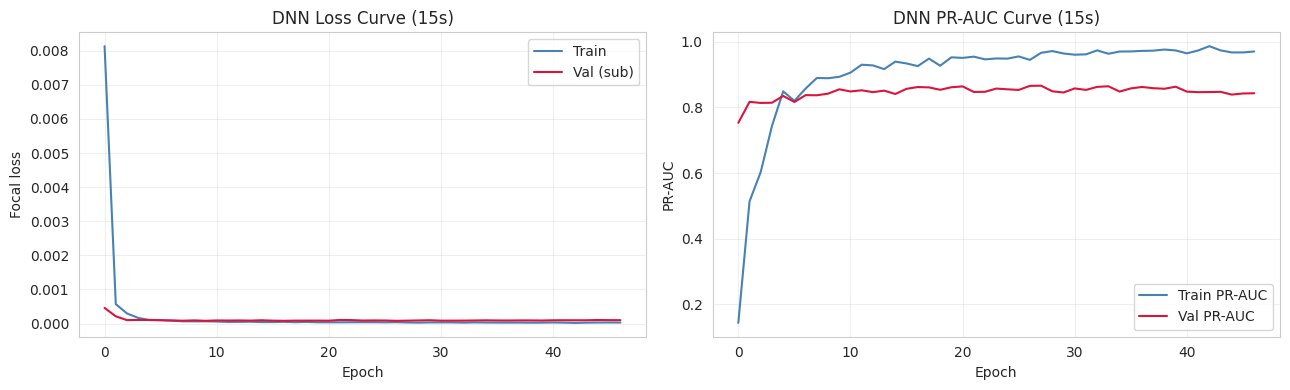


--- Train/Val gap (overfitting probe) ---
  5s: fit_F1=0.8014  val_F1=0.7816  gap=+0.0198
  15s: fit_F1=0.9184  val_F1=0.8791  gap=+0.0393
  25s: fit_F1=0.9063  val_F1=0.8723  gap=+0.0340


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print('=' * 70)
print('MODEL 5: Deep Neural Network (Focal Loss)')
print('=' * 70)
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')
print(f'TF version: {tf.__version__}')

tf.random.set_seed(42)
np.random.seed(42)


def focal_loss(gamma=2.0, alpha=0.25):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        ce = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
        return tf.reduce_mean(alpha_t * tf.pow(1 - p_t, gamma) * ce)
    return loss_fn


def build_dnn(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256), layers.BatchNormalization(), layers.Activation('relu'), layers.Dropout(0.4),
        layers.Dense(128), layers.BatchNormalization(), layers.Activation('relu'), layers.Dropout(0.4),
        layers.Dense(64),  layers.BatchNormalization(), layers.Activation('relu'), layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid'),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=focal_loss(gamma=2.0, alpha=0.25),
        metrics=[keras.metrics.AUC(name='auc'),
                 keras.metrics.AUC(curve='PR', name='pr_auc'),
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall')],
    )
    return model


dnn_models = {}
dnn_train_val_gap = {}

for resolution in ['5s', '15s', '25s']:
    print(f"\n{'-' * 60}\n  Resolution: {resolution}\n{'-' * 60}")
    split = splits_clean[resolution]
    X_fit_raw, y_fit_raw, groups_fit = get_raw_group_rows(resolution, split['groups_fit'])
    X_val_raw, y_val_raw, _ = get_raw_group_rows(resolution, split['groups_val'])

    assert len(set(groups_fit) & set(split['groups_val'])) == 0
    assert len(set(groups_fit) & set(split['groups_test'])) == 0

    # Group-aware sub-validation inside train_fit for early stopping.
    gss_val = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
    sub_train_idx, sub_val_idx = next(gss_val.split(X_fit_raw, y_fit_raw, groups_fit))
    assert len(set(groups_fit[sub_train_idx]) & set(groups_fit[sub_val_idx])) == 0

    scaler_dnn = StandardScaler()
    X_sub_tr = scaler_dnn.fit_transform(X_fit_raw[sub_train_idx])
    X_sub_val = scaler_dnn.transform(X_fit_raw[sub_val_idx])
    X_val = scaler_dnn.transform(X_val_raw)
    y_sub_tr = y_fit_raw[sub_train_idx]
    y_sub_val = y_fit_raw[sub_val_idx]

    print(f'  DNN sub-train: {len(X_sub_tr):,} rows ({int(y_sub_tr.sum())} pumps)')
    print(f'  DNN sub-val:   {len(X_sub_val):,} rows ({int(y_sub_val.sum())} pumps)')
    print(f'  splits_clean val: {len(X_val):,} rows ({int(y_val_raw.sum())} pumps)')

    keras.backend.clear_session()
    tf.random.set_seed(42)
    model = build_dnn(input_dim=X_sub_tr.shape[1])
    if resolution == '5s':
        model.summary()

    callbacks = [
        EarlyStopping(monitor='val_loss', mode='min', patience=20,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8,
                          min_lr=1e-6, verbose=0),
    ]

    print('  Training (focal loss)...')
    t0 = time.time()
    history = model.fit(
        X_sub_tr, y_sub_tr,
        validation_data=(X_sub_val, y_sub_val),
        epochs=100, batch_size=512,
        callbacks=callbacks, verbose=0,
    )
    train_time = time.time() - t0
    print(f"  (trained in {train_time:.1f}s, stopped at epoch {len(history.history['loss'])})")

    # Probe sub-train F1 vs splits_clean val F1 for an overfitting estimate.
    sub_proba = model.predict(X_sub_tr, verbose=0).ravel()
    sub_f1 = f1_score(y_sub_tr, (sub_proba >= 0.5).astype(int), zero_division=0)

    evaluate_model(model, X_val, y_val_raw,
                   model_name='DNN', resolution=resolution,
                   imbalance_strategy='focal_loss', train_time=train_time,
                   evaluation_set='val')
    val_row = next(r for r in reversed(results_log)
                   if r['model'] == 'DNN' and r['resolution'] == resolution
                   and r['evaluation_set'] == 'val')
    gap = sub_f1 - val_row['f1']
    dnn_train_val_gap[resolution] = {'fit_f1': sub_f1, 'val_f1': val_row['f1'], 'gap': gap}
    print(f'  DNN: SubTrain F1={sub_f1:.4f} | Val F1={val_row["f1"]:.4f} | Gap={gap:+.4f}')

    dnn_models[f'DNN_{resolution}'] = (model, history, scaler_dnn)

print('\n' + '=' * 70)
print('DNN - validation experiments complete')
print('=' * 70)
dnn_results = pd.DataFrame([r for r in results_log
                            if r['model'] == 'DNN' and r['evaluation_set'] == 'val'])
dnn_results = dnn_results.sort_values('f1', ascending=False)
print(dnn_results[['resolution', 'precision', 'recall', 'f1',
                   'pr_auc', 'tp', 'fp', 'train_time_s']].to_string(index=False))

best_dnn_res = dnn_results.iloc[0]['resolution']
_, best_history, _ = dnn_models[f'DNN_{best_dnn_res}']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(best_history.history['loss'], label='Train', color='steelblue')
axes[0].plot(best_history.history['val_loss'], label='Val (sub)', color='crimson')
axes[0].set_title(f'DNN Loss Curve ({best_dnn_res})')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Focal loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(best_history.history['pr_auc'], label='Train PR-AUC', color='steelblue')
axes[1].plot(best_history.history['val_pr_auc'], label='Val PR-AUC', color='crimson')
axes[1].set_title(f'DNN PR-AUC Curve ({best_dnn_res})')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('PR-AUC'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('dnn_training_curves.png', dpi=100, bbox_inches='tight')
plt.show()

print('\n--- Train/Val gap (overfitting probe) ---')
for res, g in dnn_train_val_gap.items():
    print(f'  {res}: fit_F1={g["fit_f1"]:.4f}  val_F1={g["val_f1"]:.4f}  gap={g["gap"]:+.4f}')


# 6. Model Selection and Robustness

## 6.1 Validation-Based Selection and Single Test Evaluation

This section chooses the final model using validation performance, tunes the operating threshold on validation data, and then evaluates the selected model once on the held-out test set. That order is important: the test set stays reserved for the final estimate rather than being used repeatedly during model selection.


In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score, average_precision_score

print('=' * 70)
print('MODEL SELECTION (val) + SINGLE FINAL TEST EVALUATION')
print('=' * 70)

THRESHOLD_GRID = np.linspace(0.01, 0.99, 99)


def get_proba(model, X):
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, 'decision_function'):
        scores = model.decision_function(X)
        return (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
    return model.predict(X, verbose=0).ravel()


def find_optimal_threshold_from_scores(y_true, y_proba):
    f1_vals = [
        f1_score(y_true, (y_proba >= tau).astype(int), zero_division=0)
        for tau in THRESHOLD_GRID
    ]
    best_idx = int(np.argmax(f1_vals))
    return float(THRESHOLD_GRID[best_idx]), float(f1_vals[best_idx])


def get_val_arrays_for_model(resolution, model_name):
    sp = splits_clean[resolution]
    if model_name == 'DNN':
        _, _, dnn_scaler = dnn_models[f'DNN_{resolution}']
        X_val_raw, y_val_raw, _ = get_raw_group_rows(resolution, sp['groups_val'])
        assert np.array_equal(sp['y_val'], y_val_raw)
        return dnn_scaler.transform(X_val_raw), sp['y_val']
    return sp['X_val'], sp['y_val']


def get_test_arrays_for_model(resolution, model_name):
    sp = splits_clean[resolution]
    if model_name == 'DNN':
        _, _, dnn_scaler = dnn_models[f'DNN_{resolution}']
        X_test_raw, y_test_raw, _ = get_raw_group_rows(resolution, sp['groups_test'])
        assert np.array_equal(sp['y_test'], y_test_raw)
        return dnn_scaler.transform(X_test_raw), sp['y_test']
    return sp['X_test'], sp['y_test']


models_by_resolution = {
    '5s':  {'Random Forest': rf_models['RF_5s_weighted'],
            'XGBoost':       xgb_models['XGB_5s'],
            'SVM-Linear':    svm_models['SVM_LIN_5s'],
            'DNN':           dnn_models['DNN_5s'][0],
            'Naive Bayes':   nb_models['NB_5s_weighted']},
    '15s': {'Random Forest': rf_models['RF_15s_weighted'],
            'XGBoost':       xgb_models['XGB_15s'],
            'SVM-Linear':    svm_models['SVM_LIN_15s'],
            'DNN':           dnn_models['DNN_15s'][0],
            'Naive Bayes':   nb_models['NB_15s_weighted']},
    '25s': {'Random Forest': rf_models['RF_25s_weighted'],
            'XGBoost':       xgb_models['XGB_25s'],
            'SVM-Linear':    svm_models['SVM_LIN_25s'],
            'DNN':           dnn_models['DNN_25s'][0],
            'Naive Bayes':   nb_models['NB_25s_weighted']},
}


# ---------- Step 1: validation-tuned thresholds for every (model, resolution) ----------
val_tuning = {}
for resolution in ['5s', '15s', '25s']:
    val_tuning[resolution] = {}
    for name, model in models_by_resolution[resolution].items():
        X_val, y_val = get_val_arrays_for_model(resolution, name)
        val_proba = get_proba(model, X_val)
        tau, val_f1 = find_optimal_threshold_from_scores(y_val, val_proba)
        val_pred = (val_proba >= tau).astype(int)
        val_tuning[resolution][name] = {
            'tau': tau,
            'val_f1': val_f1,
            'val_precision': precision_score(y_val, val_pred, zero_division=0),
            'val_recall': recall_score(y_val, val_pred, zero_division=0),
            'val_pr_auc': average_precision_score(y_val, val_proba),
        }

# ---------- Print validation leaderboard ----------
print('\nValidation leaderboard (val-tuned threshold; this is what selection sees)')
print('-' * 90)
header = f"{'Model':<14}{'Res':<6}{'tau':>8}{'Val F1':>10}{'Val Prec':>11}{'Val Recall':>13}{'Val PR-AUC':>12}"
print(header)
print('-' * 90)
flat = []
for res in ['5s', '15s', '25s']:
    for name, rec in val_tuning[res].items():
        flat.append((name, res, rec))
flat.sort(key=lambda r: -r[2]['val_f1'])
for name, res, rec in flat:
    print(f"{name:<14}{res:<6}{rec['tau']:>8.2f}{rec['val_f1']:>10.4f}"
          f"{rec['val_precision']:>11.4f}{rec['val_recall']:>13.4f}{rec['val_pr_auc']:>12.4f}")

# Append val-tuned rows to results_log so the master table reflects them.
results_log = [r for r in results_log if r.get('imbalance') != 'val_tuned_threshold']
for name, res, rec in flat:
    sp = splits_clean[res]
    X_val, y_val = get_val_arrays_for_model(res, name)
    val_proba = get_proba(models_by_resolution[res][name], X_val)
    val_pred = (val_proba >= rec['tau']).astype(int)
    cm = confusion_matrix(y_val, val_pred)
    tn, fp, fn, tp = cm.ravel()
    results_log.append({
        'model': name, 'resolution': res, 'imbalance': 'val_tuned_threshold',
        'evaluation_set': 'val',
        'precision': rec['val_precision'],
        'recall': rec['val_recall'],
        'f1': rec['val_f1'],
        'roc_auc': roc_auc_score(y_val, val_proba),
        'pr_auc': rec['val_pr_auc'],
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
        'threshold': rec['tau'], 'train_time_s': 0,
    })

# ---------- Step 2: pick the winner on val-tuned F1 ----------
BEST_MODEL_NAME, BEST_RESOLUTION, _BEST_REC = flat[0]
BEST_TAU = _BEST_REC['tau']
BEST_MODEL = models_by_resolution[BEST_RESOLUTION][BEST_MODEL_NAME]

print('\n' + '=' * 70)
print(f'SELECTED: {BEST_MODEL_NAME} @ {BEST_RESOLUTION}  (val-tuned tau = {BEST_TAU:.2f})')
print('=' * 70)
print('Selection criterion: maximum val-tuned F1 across all models x resolutions.')
print('Test set has NOT been touched up to this point.')

# ---------- Step 3: ONE final evaluation on the held-out test partition ----------
print('\n--- Final evaluation on held-out test set (single read) ---')
X_test_final, y_test_final = get_test_arrays_for_model(BEST_RESOLUTION, BEST_MODEL_NAME)
test_proba_final = get_proba(BEST_MODEL, X_test_final)

# (a) default threshold
final_default = evaluate_model(
    BEST_MODEL, X_test_final, y_test_final,
    model_name=BEST_MODEL_NAME, resolution=BEST_RESOLUTION,
    imbalance_strategy='class_weight' if BEST_MODEL_NAME != 'DNN' else 'focal_loss',
    threshold=0.5, evaluation_set='test',
)
# (b) val-tuned threshold
final_tuned = evaluate_model(
    BEST_MODEL, X_test_final, y_test_final,
    model_name=BEST_MODEL_NAME, resolution=BEST_RESOLUTION,
    imbalance_strategy='val_tuned_threshold',
    threshold=BEST_TAU, evaluation_set='test',
)

final_test_predictions = {
    'model_name': BEST_MODEL_NAME,
    'resolution': BEST_RESOLUTION,
    'tau': BEST_TAU,
    'X_test': X_test_final,
    'y_test': y_test_final,
    'y_proba': test_proba_final,
    'y_pred_default': (test_proba_final >= 0.5).astype(int),
    'y_pred_tuned': (test_proba_final >= BEST_TAU).astype(int),
    'metrics_default': final_default,
    'metrics_tuned': final_tuned,
}

print('\n' + '=' * 70)
print(f'FINAL TEST RESULT — {BEST_MODEL_NAME} @ {BEST_RESOLUTION}')
print('=' * 70)
print(f"  Default tau = 0.50    -> F1 = {final_default['f1']:.4f}  "
      f"P = {final_default['precision']:.4f}  R = {final_default['recall']:.4f}")
print(f"  Val-tuned tau = {BEST_TAU:.2f}  -> F1 = {final_tuned['f1']:.4f}  "
      f"P = {final_tuned['precision']:.4f}  R = {final_tuned['recall']:.4f}")
print(f"  PR-AUC = {final_default['pr_auc']:.4f} | ROC-AUC = {final_default['roc_auc']:.4f}")


MODEL SELECTION (val) + SINGLE FINAL TEST EVALUATION

Validation leaderboard (val-tuned threshold; this is what selection sees)
------------------------------------------------------------------------------------------
Model         Res        tau    Val F1   Val Prec   Val Recall  Val PR-AUC
------------------------------------------------------------------------------------------
Random Forest 15s       0.66    0.9167     0.9778       0.8627      0.9575
Random Forest 25s       0.74    0.9167     0.9778       0.8627      0.9586
DNN           25s       0.41    0.9000     0.9184       0.8824      0.9548
DNN           15s       0.44    0.8817     0.9762       0.8039      0.9494
SVM-Linear    25s       0.15    0.8660     0.9130       0.8235      0.9001
XGBoost       15s       0.99    0.8491     0.8182       0.8824      0.9334
Random Forest 5s        0.78    0.8485     0.8750       0.8235      0.9015
XGBoost       25s       0.97    0.8381     0.8148       0.8627      0.9289
SVM-Linear    1

## 6.2 Event-Level Bootstrap Confidence Intervals

Point estimates are useful, but they do not show how much uncertainty remains. This section bootstraps at the event level, not just the row level, so the confidence intervals respect the grouped structure of pump events.


Bootstrap event-level CIs for the selected model on test

Selected model: Random Forest @ 15s | val-tuned tau = 0.66
  Test F1     = 0.8833  95% CI [0.8182, 0.9431]
  Test Prec   = 0.9298  95% CI [0.8485, 1.0000]
  Test Recall = 0.8413  95% CI [0.7459, 0.9344]
  Test PR-AUC = 0.9528  95% CI [0.9142, 0.9828]


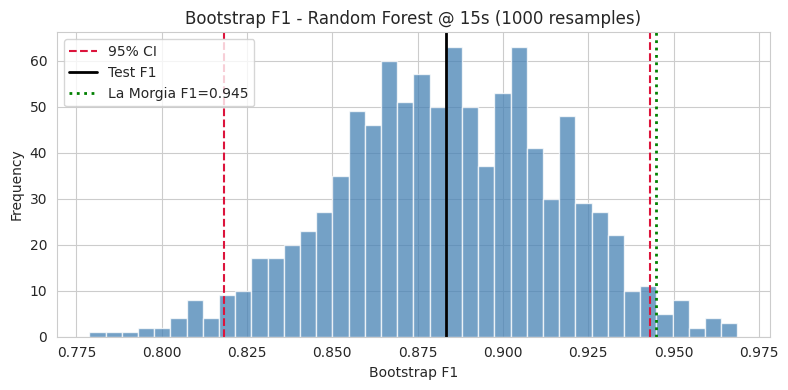


SOTA comparison rule:
  P(bootstrap F1 > 0.945) = 2.2%


In [ ]:
print('=' * 70)
print('Bootstrap event-level CIs for the selected model on test')
print('=' * 70)

y_test_final = final_test_predictions['y_test']
test_groups = splits_clean[final_test_predictions['resolution']]['groups_test']
y_proba_final = final_test_predictions['y_proba']
tau = final_test_predictions['tau']


def bootstrap_event_metrics(y, groups, y_proba, tau, n_iter=1000, seed=42):
    rng = np.random.RandomState(seed)
    y_pred = (y_proba >= tau).astype(int)
    unique_events = np.unique(groups)
    event_rows = {ev: np.where(groups == ev)[0] for ev in unique_events}
    f1s, precs, recs, prauc = [], [], [], []
    for _ in range(n_iter):
        sampled = rng.choice(unique_events, size=len(unique_events), replace=True)
        boot_idx = np.concatenate([event_rows[ev] for ev in sampled])
        if len(boot_idx) == 0 or y[boot_idx].sum() == 0:
            continue
        f1s.append(f1_score(y[boot_idx], y_pred[boot_idx], zero_division=0))
        precs.append(precision_score(y[boot_idx], y_pred[boot_idx], zero_division=0))
        recs.append(recall_score(y[boot_idx], y_pred[boot_idx], zero_division=0))
        prauc.append(average_precision_score(y[boot_idx], y_proba[boot_idx]))
    return np.array(f1s), np.array(precs), np.array(recs), np.array(prauc)


f1s, precs, recs, prauc = bootstrap_event_metrics(
    y_test_final, test_groups, y_proba_final, tau, n_iter=1000)

best_name = final_test_predictions['model_name']
best_res = final_test_predictions['resolution']
print(f"\nSelected model: {best_name} @ {best_res} | val-tuned tau = {tau:.2f}")
print(f"  Test F1     = {final_test_predictions['metrics_tuned']['f1']:.4f}  "
      f"95% CI [{np.percentile(f1s, 2.5):.4f}, {np.percentile(f1s, 97.5):.4f}]")
print(f"  Test Prec   = {final_test_predictions['metrics_tuned']['precision']:.4f}  "
      f"95% CI [{np.percentile(precs, 2.5):.4f}, {np.percentile(precs, 97.5):.4f}]")
print(f"  Test Recall = {final_test_predictions['metrics_tuned']['recall']:.4f}  "
      f"95% CI [{np.percentile(recs, 2.5):.4f}, {np.percentile(recs, 97.5):.4f}]")
print(f"  Test PR-AUC = {final_test_predictions['metrics_tuned']['pr_auc']:.4f}  "
      f"95% CI [{np.percentile(prauc, 2.5):.4f}, {np.percentile(prauc, 97.5):.4f}]")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(f1s, bins=40, color='steelblue', alpha=0.75, edgecolor='white')
ax.axvline(np.percentile(f1s, 2.5), color='crimson', linestyle='--', label='95% CI')
ax.axvline(np.percentile(f1s, 97.5), color='crimson', linestyle='--')
ax.axvline(final_test_predictions['metrics_tuned']['f1'],
           color='black', linewidth=2, label='Test F1')
ax.axvline(0.945, color='green', linewidth=2, linestyle=':', label='La Morgia F1=0.945')
ax.set_xlabel('Bootstrap F1')
ax.set_ylabel('Frequency')
ax.set_title(f'Bootstrap F1 - {best_name} @ {best_res} (1000 resamples)')
ax.legend()
plt.tight_layout()
plt.savefig('bootstrap_f1_ci.png', dpi=100, bbox_inches='tight')
plt.show()

print('\nSOTA comparison rule:')
print(f"  P(bootstrap F1 > 0.945) = {(f1s > 0.945).mean():.1%}")

## 6.3 Chronological Robustness Check

The chronological split is an independent robustness check. It asks whether the selected approach still performs reasonably when older events are used for training and newer events are held back for testing, which is closer to a real deployment setting.


In [ ]:
from sklearn.ensemble import RandomForestClassifier

print('=' * 70)
print('ROBUSTNESS CHECK: chronological event split (independent retrain)')
print('=' * 70)

df_25s = datasets['25s'].copy()
df_25s['date_parsed'] = pd.to_datetime(df_25s['date'])
CUTOFF = pd.Timestamp('2020-01-01')

positive_event_dates = (
    df_25s[df_25s[TARGET_COL] == 1].groupby(GROUP_COL)['date_parsed'].min()
)
fallback_event_dates = df_25s.groupby(GROUP_COL)['date_parsed'].min()
event_dates = fallback_event_dates.copy()
event_dates.update(positive_event_dates)

train_events = set(event_dates[event_dates < CUTOFF].index)
test_events = set(event_dates[event_dates >= CUTOFF].index)
assert len(train_events & test_events) == 0

mask_train = df_25s[GROUP_COL].isin(train_events)
mask_test = df_25s[GROUP_COL].isin(test_events)
X_chrono_train = df_25s.loc[mask_train, FEATURE_COLS].values
y_chrono_train = df_25s.loc[mask_train, TARGET_COL].values
X_chrono_test = df_25s.loc[mask_test, FEATURE_COLS].values
y_chrono_test = df_25s.loc[mask_test, TARGET_COL].values

print(f'Cutoff: {CUTOFF.date()}')
print(f'  Pre-cutoff:  {len(X_chrono_train):>7,} rows | {int(y_chrono_train.sum()):>4} pumps | {len(train_events)} events')
print(f'  Post-cutoff: {len(X_chrono_test):>7,} rows | {int(y_chrono_test.sum()):>4} pumps | {len(test_events)} events')

if y_chrono_train.sum() < 50 or y_chrono_test.sum() < 50:
    print('WARNING: chronological halves are sparse; treat numbers as indicative only.')

scaler_chrono = StandardScaler()
X_chrono_train = scaler_chrono.fit_transform(X_chrono_train)
X_chrono_test = scaler_chrono.transform(X_chrono_test)
cw_chrono, _ = get_class_weights(y_chrono_train, verbose=False)

print('\nTraining RF on pre-cutoff events...')
t0 = time.time()
rf_chrono = RandomForestClassifier(**RF_PARAMS, class_weight=cw_chrono)
rf_chrono.fit(X_chrono_train, y_chrono_train)
train_time = time.time() - t0
print(f'  (trained in {train_time:.1f}s)')

y_proba_chrono = rf_chrono.predict_proba(X_chrono_test)[:, 1]
y_pred_chrono = (y_proba_chrono >= 0.5).astype(int)

f1c = f1_score(y_chrono_test, y_pred_chrono, zero_division=0)
pc = precision_score(y_chrono_test, y_pred_chrono, zero_division=0)
rc = recall_score(y_chrono_test, y_pred_chrono, zero_division=0)
prauc_c = average_precision_score(y_chrono_test, y_proba_chrono)
roc_c = roc_auc_score(y_chrono_test, y_proba_chrono)
tn, fp, fn, tp = confusion_matrix(y_chrono_test, y_pred_chrono).ravel()

print('\nChronological evaluation @ 25s (default tau=0.5):')
print(f'  Precision: {pc:.4f}')
print(f'  Recall:    {rc:.4f}')
print(f'  F1:        {f1c:.4f}')
print(f'  PR-AUC:    {prauc_c:.4f}')
print(f'  ROC-AUC:   {roc_c:.4f}')
print(f'  Confusion: TP={tp}  FP={fp}  FN={fn}  TN={tn}')

val_rf_row = next(r for r in results_log
                  if r['model'] == 'Random Forest' and r['resolution'] == '25s'
                  and r['evaluation_set'] == 'val' and r['imbalance'] == 'class_weight'
                  and abs(r['threshold'] - 0.5) < 1e-9)
print('\nReference: Random Forest @ 25s validation F1 = '
      f"{val_rf_row['f1']:.4f}  (single-split val, default tau)")
print(f'Chronological F1 vs val F1 delta = {f1c - val_rf_row["f1"]:+.4f}')

results_log.append({
    'model': 'Random Forest (chronological)',
    'resolution': '25s', 'imbalance': 'class_weight', 'evaluation_set': 'test',
    'precision': pc, 'recall': rc, 'f1': f1c,
    'roc_auc': roc_c, 'pr_auc': prauc_c,
    'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
    'threshold': 0.5, 'train_time_s': train_time,
})
print(f'\nLogged. Total experiments: {len(results_log)}')


ROBUSTNESS CHECK: chronological event split (independent retrain)
Cutoff: 2020-01-01
  Pre-cutoff:  319,108 rows |  193 pumps | 199 events
  Post-cutoff: 163,049 rows |  124 pumps | 128 events

Training RF on pre-cutoff events...
  (trained in 4.9s)

Chronological evaluation @ 25s (default tau=0.5):
  Precision: 0.9174
  Recall:    0.8952
  F1:        0.9061
  PR-AUC:    0.9597
  ROC-AUC:   0.9959
  Confusion: TP=111  FP=10  FN=13  TN=162915

Reference: Random Forest @ 25s validation F1 = 0.8932  (single-split val, default tau)
Chronological F1 vs val F1 delta = +0.0129

Logged. Total experiments: 39


# 7. Visual Evaluation

## 7.1 Precision-Recall and ROC Curves

These curves show how each model behaves across thresholds on validation data, then highlight the selected model on the final test set. PR curves are especially important here because the positive class is rare and accuracy alone would be misleading.


PR & ROC: validation (cross-model) + final test (selected model)


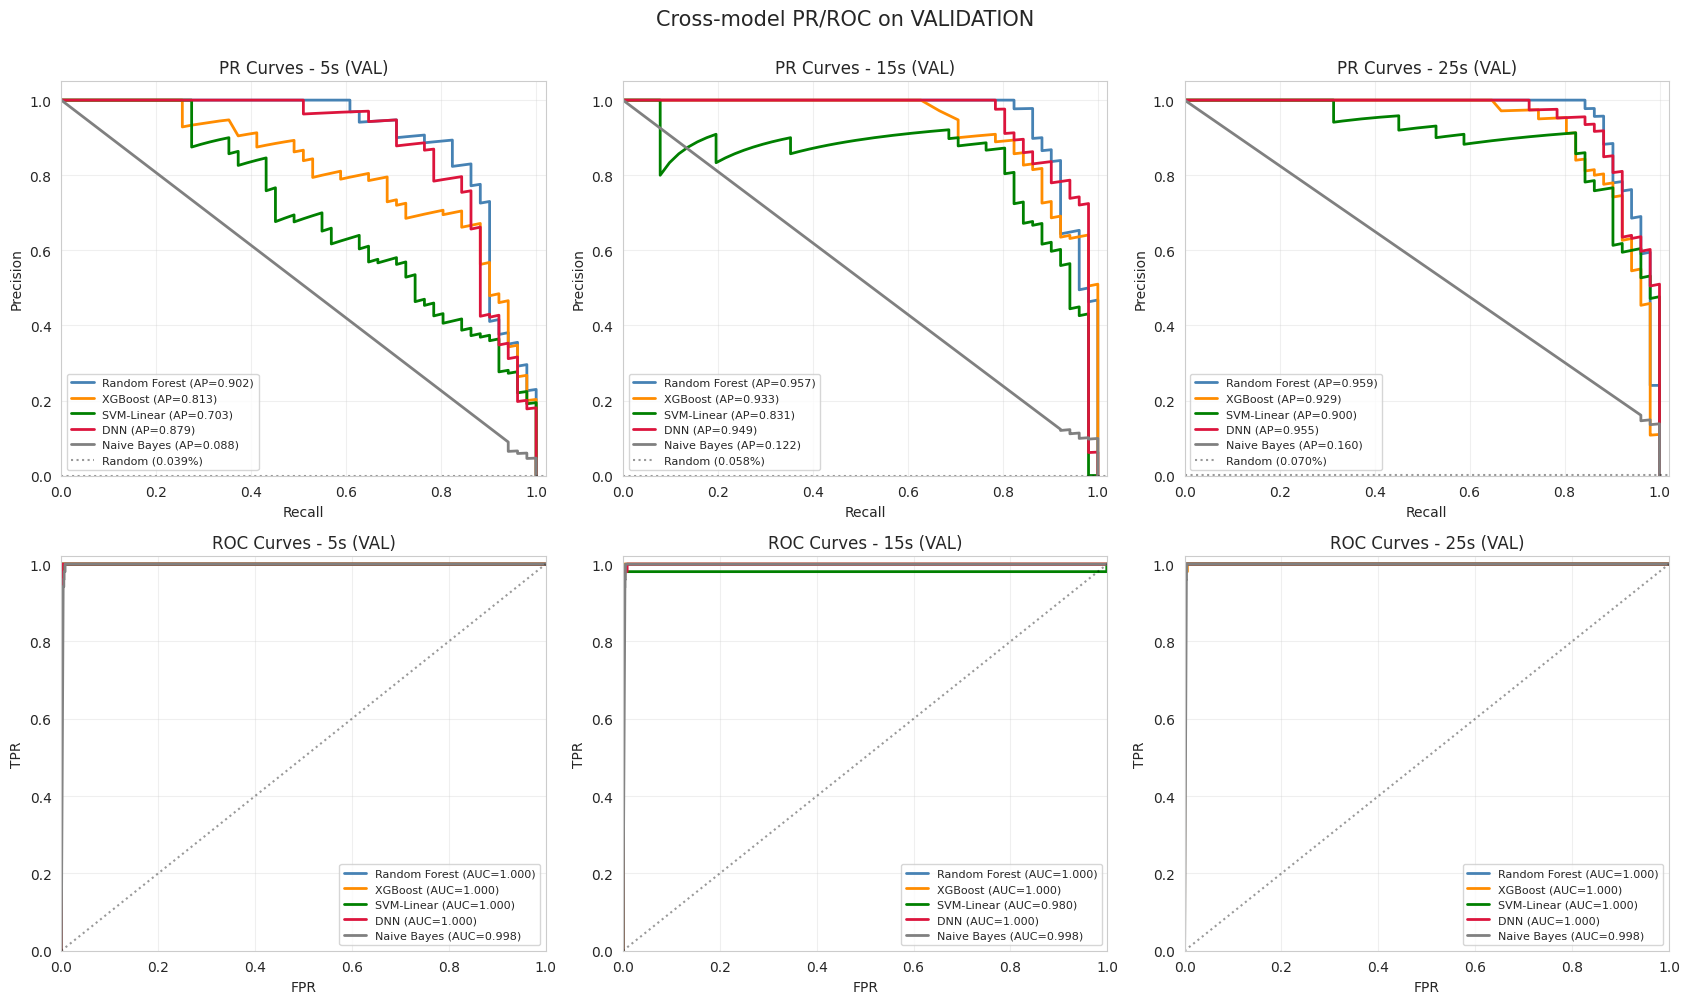

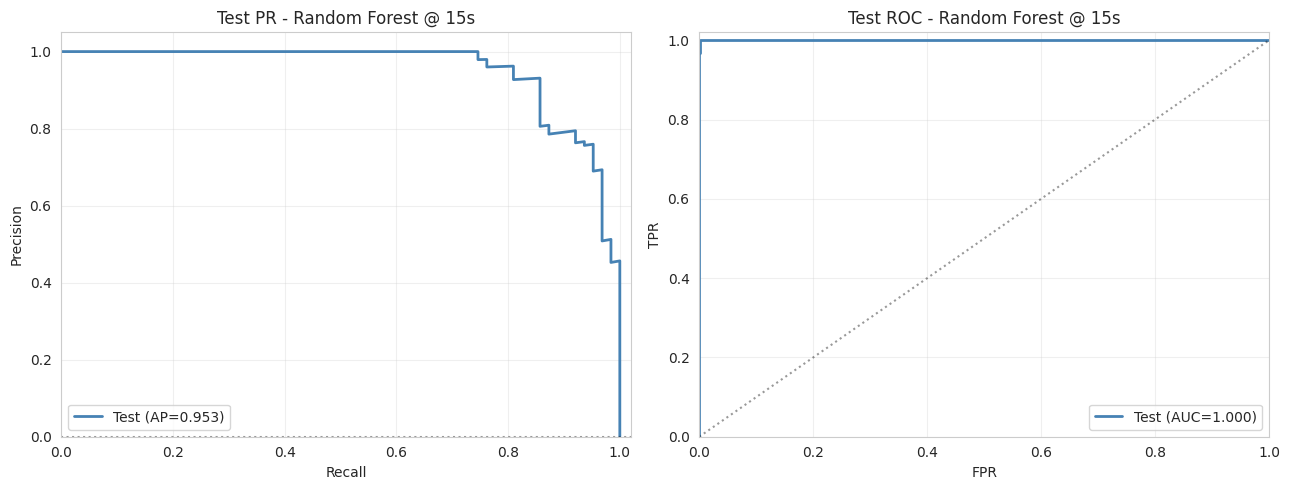


Validation summary: AP and ROC-AUC (selection regime)
Model             Resolution  AP (val)    ROC-AUC (val) 
--------------------------------------------------------
Random Forest     5s          0.9015      0.9999        
XGBoost           5s          0.8126      0.9999        
SVM-Linear        5s          0.7030      0.9998        
DNN               5s          0.8792      0.9999        
Naive Bayes       5s          0.0878      0.9979        
--------------------------------------------------------
Random Forest     15s         0.9575      1.0000        
XGBoost           15s         0.9334      0.9999        
SVM-Linear        15s         0.8309      0.9803        
DNN               15s         0.9494      0.9998        
Naive Bayes       15s         0.1223      0.9979        
--------------------------------------------------------
Random Forest     25s         0.9586      0.9999        
XGBoost           25s         0.9289      0.9998        
SVM-Linear        25s         0.9

In [ ]:
print('=' * 70)
print('PR & ROC: validation (cross-model) + final test (selected model)')
print('=' * 70)

colors = {'Random Forest': 'steelblue', 'XGBoost': 'darkorange',
          'SVM-Linear': 'green', 'DNN': 'crimson', 'Naive Bayes': 'gray'}


def get_val_arrays_local(resolution, model_name):
    sp = splits_clean[resolution]
    if model_name == 'DNN':
        _, _, dnn_scaler = dnn_models[f'DNN_{resolution}']
        X_val_raw, y_val_raw, _ = get_raw_group_rows(resolution, sp['groups_val'])
        return dnn_scaler.transform(X_val_raw), y_val_raw
    return sp['X_val'], sp['y_val']


fig, axes = plt.subplots(2, 3, figsize=(17, 10))
for col, resolution in enumerate(['5s', '15s', '25s']):
    ax_pr = axes[0, col]
    ax_roc = axes[1, col]
    pump_pct = splits_clean[resolution]['y_val'].mean() * 100

    for name, model in models_by_resolution[resolution].items():
        X_val, y_val = get_val_arrays_local(resolution, name)
        y_proba = get_proba(model, X_val)
        precision, recall, _ = precision_recall_curve(y_val, y_proba)
        ap = average_precision_score(y_val, y_proba)
        ax_pr.plot(recall, precision, label=f'{name} (AP={ap:.3f})',
                   color=colors[name], linewidth=2)

        fpr, tpr, _ = roc_curve(y_val, y_proba)
        auc = roc_auc_score(y_val, y_proba)
        ax_roc.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})',
                    color=colors[name], linewidth=2)

    ax_pr.axhline(splits_clean[resolution]['y_val'].mean(), color='black',
                  linestyle=':', alpha=0.4, label=f'Random ({pump_pct:.3f}%)')
    ax_pr.set_xlabel('Recall'); ax_pr.set_ylabel('Precision')
    ax_pr.set_title(f'PR Curves - {resolution} (VAL)')
    ax_pr.legend(fontsize=8, loc='lower left'); ax_pr.grid(alpha=0.3)
    ax_pr.set_xlim(0, 1.02); ax_pr.set_ylim(0, 1.05)

    ax_roc.plot([0, 1], [0, 1], color='black', linestyle=':', alpha=0.4)
    ax_roc.set_xlabel('FPR'); ax_roc.set_ylabel('TPR')
    ax_roc.set_title(f'ROC Curves - {resolution} (VAL)')
    ax_roc.legend(fontsize=8, loc='lower right'); ax_roc.grid(alpha=0.3)
    ax_roc.set_xlim(0, 1); ax_roc.set_ylim(0, 1.02)

plt.suptitle('Cross-model PR/ROC on VALIDATION', fontsize=15, y=1.00)
plt.tight_layout()
plt.savefig('pr_roc_curves_validation.png', dpi=100, bbox_inches='tight')
plt.show()

# --- Final TEST PR/ROC for SELECTED model only ---
y_test_final = final_test_predictions['y_test']
y_proba_final = final_test_predictions['y_proba']
prec_t, rec_t, _ = precision_recall_curve(y_test_final, y_proba_final)
fpr_t, tpr_t, _ = roc_curve(y_test_final, y_proba_final)
ap_t = average_precision_score(y_test_final, y_proba_final)
auc_t = roc_auc_score(y_test_final, y_proba_final)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(rec_t, prec_t, color='steelblue', linewidth=2,
             label=f'Test (AP={ap_t:.3f})')
axes[0].axhline(y_test_final.mean(), color='black', linestyle=':', alpha=0.4)
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title(f'Test PR - {final_test_predictions["model_name"]} @ {final_test_predictions["resolution"]}')
axes[0].legend(); axes[0].grid(alpha=0.3); axes[0].set_xlim(0, 1.02); axes[0].set_ylim(0, 1.05)

axes[1].plot(fpr_t, tpr_t, color='steelblue', linewidth=2,
             label=f'Test (AUC={auc_t:.3f})')
axes[1].plot([0, 1], [0, 1], color='black', linestyle=':', alpha=0.4)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title(f'Test ROC - {final_test_predictions["model_name"]} @ {final_test_predictions["resolution"]}')
axes[1].legend(); axes[1].grid(alpha=0.3); axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1.02)

plt.tight_layout()
plt.savefig('pr_roc_test_selected.png', dpi=100, bbox_inches='tight')
plt.show()

print('\nValidation summary: AP and ROC-AUC (selection regime)')
print(f"{'Model':<18}{'Resolution':<12}{'AP (val)':<12}{'ROC-AUC (val)':<14}")
print('-' * 56)
for resolution in ['5s', '15s', '25s']:
    for name, model in models_by_resolution[resolution].items():
        X_val, y_val = get_val_arrays_local(resolution, name)
        y_proba = get_proba(model, X_val)
        ap = average_precision_score(y_val, y_proba)
        auc = roc_auc_score(y_val, y_proba)
        print(f'{name:<18}{resolution:<12}{ap:<12.4f}{auc:<14.4f}')
    print('-' * 56)


## 7.2 Confusion Matrices

The confusion matrices translate the metric scores into concrete error counts. This makes it easier to see the practical tradeoff between catching pump events and incorrectly flagging normal market behavior.


Confusion matrices: validation (cross-model) + final test (selected)


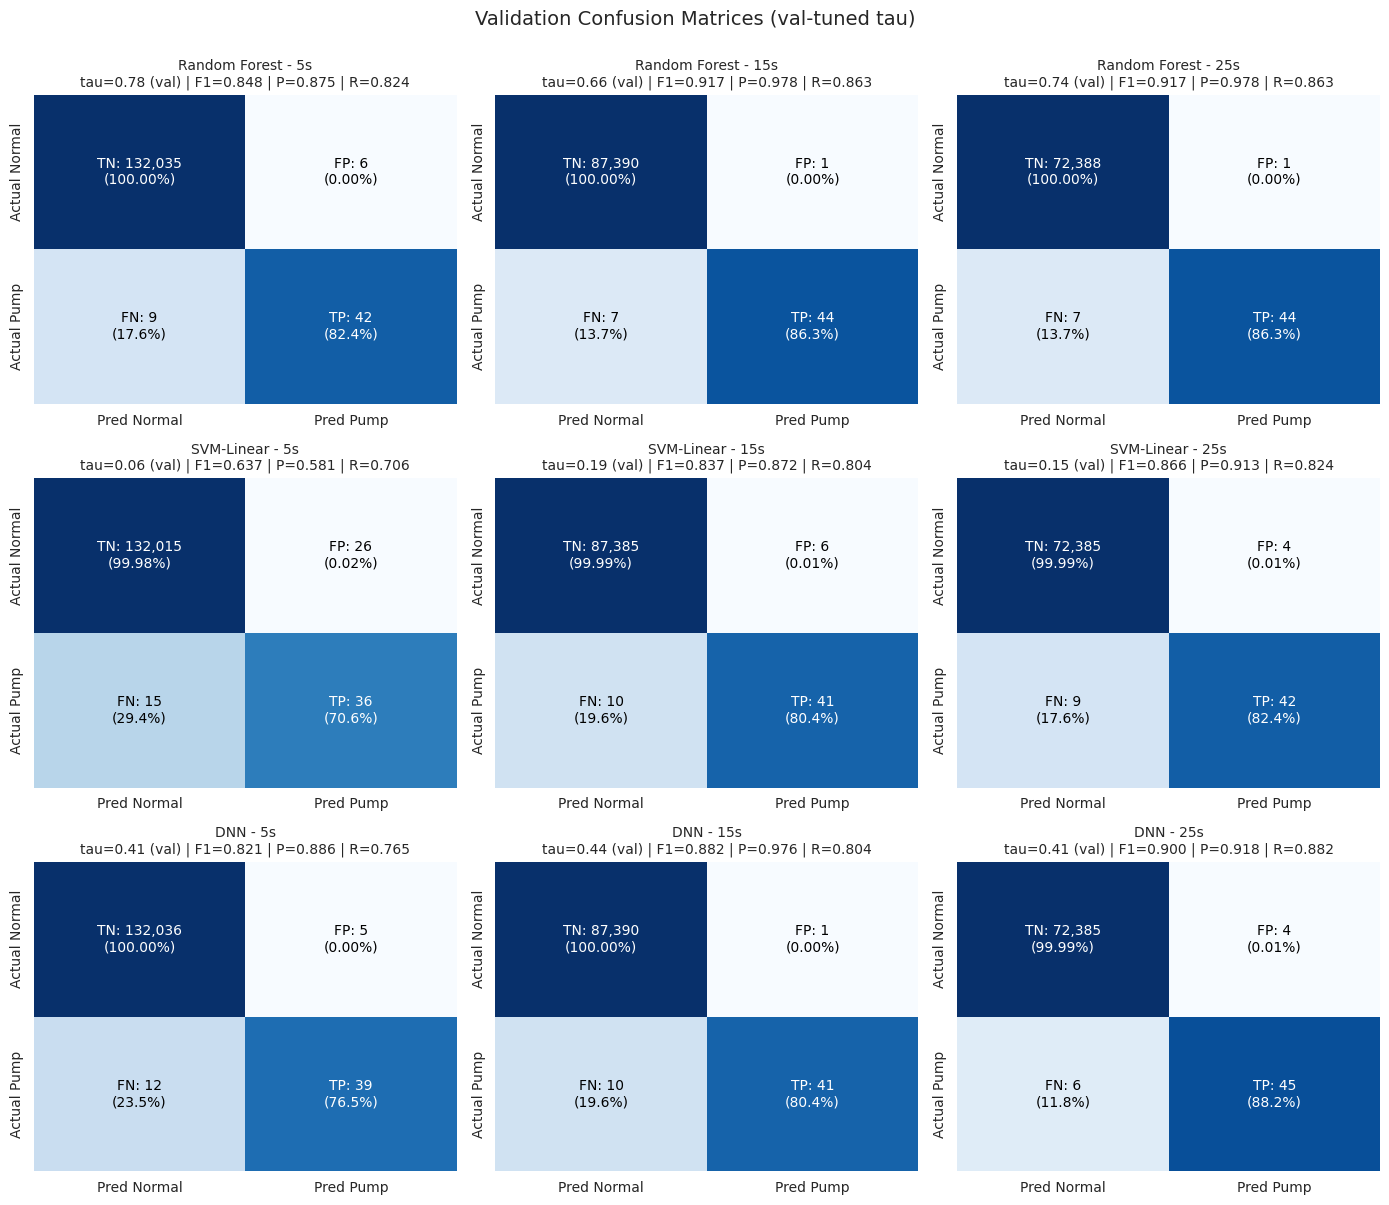

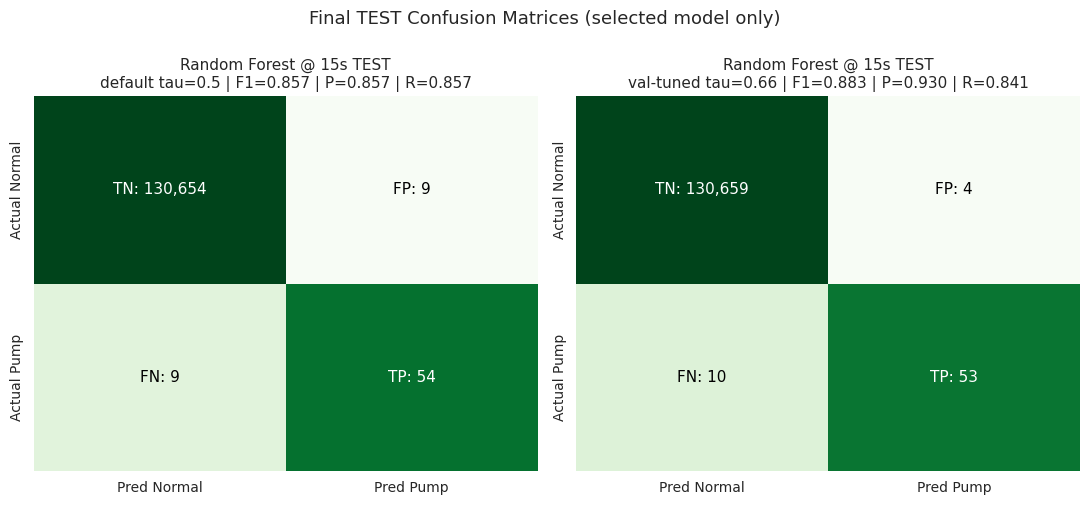

In [ ]:
print('=' * 70)
print('Confusion matrices: validation (cross-model) + final test (selected)')
print('=' * 70)

top_models = {
    'Random Forest': {res: rf_models[f'RF_{res}_weighted']  for res in ['5s', '15s', '25s']},
    'SVM-Linear':    {res: svm_models[f'SVM_LIN_{res}']     for res in ['5s', '15s', '25s']},
    'DNN':           {res: dnn_models[f'DNN_{res}'][0]      for res in ['5s', '15s', '25s']},
}


def get_val_arrays_local2(resolution, model_name):
    sp = splits_clean[resolution]
    if model_name == 'DNN':
        _, _, dnn_scaler = dnn_models[f'DNN_{resolution}']
        X_val_raw, y_val_raw, _ = get_raw_group_rows(resolution, sp['groups_val'])
        return dnn_scaler.transform(X_val_raw), y_val_raw
    return sp['X_val'], sp['y_val']


fig, axes = plt.subplots(3, 3, figsize=(14, 12))
for row, (model_name, models_dict) in enumerate(top_models.items()):
    for col, resolution in enumerate(['5s', '15s', '25s']):
        ax = axes[row, col]
        rec = val_tuning[resolution][model_name]
        tau = rec['tau']
        X_val, y_val = get_val_arrays_local2(resolution, model_name)
        y_proba = get_proba(models_dict[resolution], X_val)
        y_pred = (y_proba >= tau).astype(int)
        cm = confusion_matrix(y_val, y_pred)
        tn, fp, fn, tp = cm.ravel()
        cm_pct = cm.astype(float)
        cm_pct[0] = cm_pct[0] / max(cm_pct[0].sum(), 1) * 100
        cm_pct[1] = cm_pct[1] / max(cm_pct[1].sum(), 1) * 100
        sns.heatmap(cm_pct, annot=False, cmap='Blues', cbar=False, ax=ax,
                    xticklabels=['Pred Normal', 'Pred Pump'],
                    yticklabels=['Actual Normal', 'Actual Pump'])
        ax.text(0.5, 0.5, f'TN: {tn:,}\n({cm_pct[0,0]:.2f}%)',
                ha='center', va='center', fontsize=10,
                color='white' if cm_pct[0, 0] > 50 else 'black')
        ax.text(1.5, 0.5, f'FP: {fp}\n({cm_pct[0,1]:.2f}%)',
                ha='center', va='center', fontsize=10, color='black')
        ax.text(0.5, 1.5, f'FN: {fn}\n({cm_pct[1,0]:.1f}%)',
                ha='center', va='center', fontsize=10, color='black')
        ax.text(1.5, 1.5, f'TP: {tp}\n({cm_pct[1,1]:.1f}%)',
                ha='center', va='center', fontsize=10,
                color='white' if cm_pct[1, 1] > 50 else 'black')
        f1v = rec['val_f1']; pv = rec['val_precision']; rv = rec['val_recall']
        ax.set_title(f'{model_name} - {resolution}\n'
                     f'tau={tau:.2f} (val) | F1={f1v:.3f} | P={pv:.3f} | R={rv:.3f}',
                     fontsize=10)

plt.suptitle('Validation Confusion Matrices (val-tuned tau)', fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig('confusion_matrices_validation.png', dpi=100, bbox_inches='tight')
plt.show()

# --- Final TEST confusion matrix for SELECTED model ---
y_t = final_test_predictions['y_test']
yp_def = final_test_predictions['y_pred_default']
yp_tun = final_test_predictions['y_pred_tuned']
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, yp, title, tau in [
    (axes[0], yp_def, 'default tau=0.5', 0.5),
    (axes[1], yp_tun, f'val-tuned tau={final_test_predictions["tau"]:.2f}',
     final_test_predictions['tau']),
]:
    cm = confusion_matrix(y_t, yp)
    tn, fp, fn, tp = cm.ravel()
    cm_pct = cm.astype(float)
    cm_pct[0] = cm_pct[0] / max(cm_pct[0].sum(), 1) * 100
    cm_pct[1] = cm_pct[1] / max(cm_pct[1].sum(), 1) * 100
    sns.heatmap(cm_pct, annot=False, cmap='Greens', cbar=False, ax=ax,
                xticklabels=['Pred Normal', 'Pred Pump'],
                yticklabels=['Actual Normal', 'Actual Pump'])
    ax.text(0.5, 0.5, f'TN: {tn:,}', ha='center', va='center', fontsize=11,
            color='white' if cm_pct[0, 0] > 50 else 'black')
    ax.text(1.5, 0.5, f'FP: {fp}', ha='center', va='center', fontsize=11, color='black')
    ax.text(0.5, 1.5, f'FN: {fn}', ha='center', va='center', fontsize=11, color='black')
    ax.text(1.5, 1.5, f'TP: {tp}', ha='center', va='center', fontsize=11,
            color='white' if cm_pct[1, 1] > 50 else 'black')
    f1t = f1_score(y_t, yp, zero_division=0)
    pt = precision_score(y_t, yp, zero_division=0)
    rt = recall_score(y_t, yp, zero_division=0)
    ax.set_title(f'{final_test_predictions["model_name"]} @ {final_test_predictions["resolution"]} '
                 f'TEST\n{title} | F1={f1t:.3f} | P={pt:.3f} | R={rt:.3f}', fontsize=11)
plt.suptitle('Final TEST Confusion Matrices (selected model only)', fontsize=13, y=1.00)
plt.tight_layout()
plt.savefig('confusion_matrices_test_selected.png', dpi=100, bbox_inches='tight')
plt.show()


# 8. Error Analysis and Final Checks

## 8.1 False Positive and False Negative Review

After the final model is selected, this section inspects the mistakes directly. Looking at false positives and false negatives helps explain what the model is missing, where it is overreacting, and whether the errors make sense for a rare-event detection task.


Error analysis - Random Forest @ 15s (val-tuned tau)
Operating point: tau = 0.66 (chosen on val, frozen for test)

True Positives:  53
False Negatives: 10 (missed pumps)
False Positives: 4 (false alarms)

Q1: The 10 pumps we missed
               date  pump_index symbol  y_proba  std_rush_order  std_trades  std_volume  avg_volume
2020-03-25 15:56:15         157    NXS 0.639276           0.105       0.326       0.844       0.213
2020-03-27 21:00:00           7   FUEL 0.449272           0.048       0.268       0.107       0.071
2020-12-06 18:01:00         258    BRD 0.419297           0.067       0.246       0.021       0.025
2018-12-27 12:31:15         181    SUB 0.419268           0.089       0.080       0.012       0.022
2018-12-08 18:45:00          57  STORJ 0.399603           0.319       0.515       0.642       0.135
2020-05-21 15:59:00         329    GTO 0.329494           0.037       0.101       0.170       0.110
2020-03-13 16:00:15          77    TCT 0.319278           0.025     

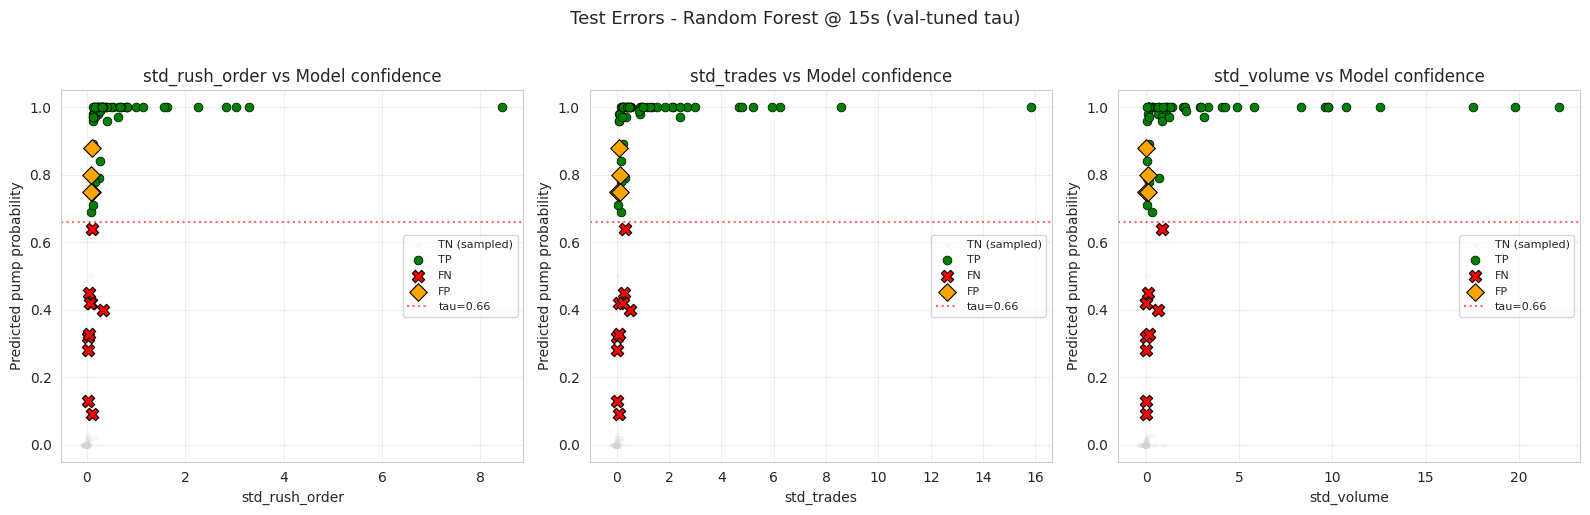

In [ ]:
print('=' * 70)
print(f'Error analysis - {final_test_predictions["model_name"]} @ '
      f'{final_test_predictions["resolution"]} (val-tuned tau)')
print('=' * 70)

opt_t = final_test_predictions['tau']
y_proba = final_test_predictions['y_proba']
y_pred = final_test_predictions['y_pred_tuned']
y_te = final_test_predictions['y_test']
res_used = final_test_predictions['resolution']
test_groups_used = splits_clean[res_used]['groups_test']

print(f"Operating point: tau = {opt_t:.2f} (chosen on val, frozen for test)\n")

fn_mask = (y_te == 1) & (y_pred == 0)
fp_mask = (y_te == 0) & (y_pred == 1)
tp_mask = (y_te == 1) & (y_pred == 1)

print(f"True Positives:  {tp_mask.sum()}")
print(f"False Negatives: {fn_mask.sum()} (missed pumps)")
print(f"False Positives: {fp_mask.sum()} (false alarms)")

df = datasets[res_used].copy()
test_event_ids = set(test_groups_used)
df_test = df[df[GROUP_COL].isin(test_event_ids)].reset_index(drop=True)
assert len(df_test) == len(y_te), 'Test set size mismatch!'

df_test['y_true'] = y_te
df_test['y_pred'] = y_pred
df_test['y_proba'] = y_proba
df_test['error_type'] = 'TN'
df_test.loc[tp_mask, 'error_type'] = 'TP'
df_test.loc[fn_mask, 'error_type'] = 'FN'
df_test.loc[fp_mask, 'error_type'] = 'FP'

print('\n' + '=' * 70)
print(f'Q1: The {fn_mask.sum()} pumps we missed')
print('=' * 70)
missed_pumps = df_test[df_test['error_type'] == 'FN'][
    ['date', 'pump_index', 'symbol', 'y_proba',
     'std_rush_order', 'std_trades', 'std_volume', 'avg_volume']
].sort_values('y_proba', ascending=False)
print(missed_pumps.to_string(index=False))

print('\n--- Feature comparison: missed vs caught pumps ---')
missed = df_test[df_test['error_type'] == 'FN'][FEATURE_COLS].mean()
caught = df_test[df_test['error_type'] == 'TP'][FEATURE_COLS].mean()
comparison = pd.DataFrame({'Caught (TP)': caught, 'Missed (FN)': missed})
comparison['Ratio (Missed/Caught)'] = comparison['Missed (FN)'] / comparison['Caught (TP)']
print(comparison.round(4).to_string())

print('\n' + '=' * 70)
print(f'Q2: The {fp_mask.sum()} false alarm(s)')
print('=' * 70)
false_alarms = df_test[df_test['error_type'] == 'FP'][
    ['date', 'pump_index', 'symbol', 'y_proba',
     'std_rush_order', 'std_trades', 'std_volume', 'avg_volume']
].sort_values('y_proba', ascending=False)
print(false_alarms.head(20).to_string(index=False))

print('\n--- Are FPs near real pumps in time? ---')
for _, fp_row in false_alarms.head(10).iterrows():
    nearest = df_test[(df_test['symbol'] == fp_row['symbol']) &
                      (df_test['y_true'] == 1)]
    if len(nearest) > 0:
        nearest_date = pd.to_datetime(nearest['date']).iloc[0]
        fp_date = pd.to_datetime(fp_row['date'])
        delta = abs((nearest_date - fp_date).total_seconds() / 60)
        print(f"  FP @ {fp_row['date']} ({fp_row['symbol']}): "
              f"nearest real pump for same coin = {delta:.0f} min away")
    else:
        print(f"  FP @ {fp_row['date']} ({fp_row['symbol']}): "
              f"no real pump for this coin in test set")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
strong_features = ['std_rush_order', 'std_trades', 'std_volume']
for i, feat in enumerate(strong_features):
    ax = axes[i]
    tn_sample = df_test[df_test['error_type'] == 'TN'].sample(
        min(5000, (df_test['error_type'] == 'TN').sum()), random_state=42)
    ax.scatter(tn_sample[feat], tn_sample['y_proba'],
               alpha=0.1, color='lightgray', s=8, label='TN (sampled)')
    tp_pts = df_test[df_test['error_type'] == 'TP']
    fn_pts = df_test[df_test['error_type'] == 'FN']
    fp_pts = df_test[df_test['error_type'] == 'FP']
    ax.scatter(tp_pts[feat], tp_pts['y_proba'], color='green', s=40,
               label='TP', edgecolor='black', linewidth=0.5)
    ax.scatter(fn_pts[feat], fn_pts['y_proba'], color='red', s=80,
               label='FN', marker='X', edgecolor='black', linewidth=0.8)
    ax.scatter(fp_pts[feat], fp_pts['y_proba'], color='orange', s=80,
               label='FP', marker='D', edgecolor='black', linewidth=0.8)
    ax.axhline(opt_t, color='red', linestyle=':', alpha=0.6, label=f'tau={opt_t:.2f}')
    ax.set_xlabel(feat); ax.set_ylabel('Predicted pump probability')
    ax.set_title(f'{feat} vs Model confidence')
    ax.legend(fontsize=8, loc='center right'); ax.grid(alpha=0.3)

plt.suptitle(f'Test Errors - {final_test_predictions["model_name"]} '
             f'@ {final_test_predictions["resolution"]} (val-tuned tau)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('error_analysis_feature_space.png', dpi=100, bbox_inches='tight')
plt.show()


## 8.2 Final Leakage and Split Integrity Audit

Before reporting the final results, this last audit re-checks that event groups do not overlap across train-fit, validation, and test sets. It is a final guardrail against accidentally reporting scores from a contaminated split.


In [ ]:
print('=' * 70)
print('Final leakage audit')
print('=' * 70)

for resolution in ['5s', '15s', '25s']:
    sp = splits_clean[resolution]
    fit_events = set(sp['groups_fit'])
    val_events = set(sp['groups_val'])
    test_events = set(sp['groups_test'])
    print(f'\n{resolution}:')
    print(f'  Train-fit events: {len(fit_events)}')
    print(f'  Validation events: {len(val_events)}')
    print(f'  Test events: {len(test_events)}')
    print(f'  Train/val overlap:  {len(fit_events & val_events)}')
    print(f'  Train/test overlap: {len(fit_events & test_events)}')
    print(f'  Val/test overlap:   {len(val_events & test_events)}')
    assert len(fit_events & val_events) == 0
    assert len(fit_events & test_events) == 0
    assert len(val_events & test_events) == 0

print('\n--- Coin overlap (informational; pump_index, not symbol, is the group key) ---')
for resolution in ['25s']:
    sp = splits_clean[resolution]
    df = datasets[resolution]
    fc = set(df[df[GROUP_COL].isin(set(sp['groups_fit']))]['symbol'].unique())
    vc = set(df[df[GROUP_COL].isin(set(sp['groups_val']))]['symbol'].unique())
    tc = set(df[df[GROUP_COL].isin(set(sp['groups_test']))]['symbol'].unique())
    print(f'  {resolution}: fit={len(fc)} val={len(vc)} test={len(tc)} | '
          f'val&fit={len(vc & fc)} | test&fit={len(tc & fc)} | test&val={len(tc & vc)}')

print('\n--- Test-set inspection trace ---')
test_rows = [r for r in results_log if r.get('evaluation_set') == 'test']
print(f'  Rows in results_log marked evaluation_set="test": {len(test_rows)}')
for r in test_rows:
    print(f'    - {r["model"]} @ {r["resolution"]} | imbalance={r["imbalance"]} | '
          f'tau={r["threshold"]:.2f} | F1={r["f1"]:.4f}')
print('  (Excludes the chronological RF retrain, which uses an independent split.)')

print('\nEvent-level split audit passed.')
print('Scaler is fit only on train_fit. Threshold tuning uses validation only.')
print(f'Selected model: {BEST_MODEL_NAME} @ {BEST_RESOLUTION} (val-tuned tau = {BEST_TAU:.2f})')


Final leakage audit

5s:
  Train-fit events: 208
  Validation events: 53
  Test events: 66
  Train/val overlap:  0
  Train/test overlap: 0
  Val/test overlap:   0

15s:
  Train-fit events: 208
  Validation events: 53
  Test events: 66
  Train/val overlap:  0
  Train/test overlap: 0
  Val/test overlap:   0

25s:
  Train-fit events: 208
  Validation events: 53
  Test events: 66
  Train/val overlap:  0
  Train/test overlap: 0
  Val/test overlap:   0

--- Coin overlap (informational; pump_index, not symbol, is the group key) ---
  25s: fit=67 val=38 test=44 | val&fit=29 | test&fit=29 | test&val=20

--- Test-set inspection trace ---
  Rows in results_log marked evaluation_set="test": 3
    - Random Forest @ 15s | imbalance=class_weight | tau=0.50 | F1=0.8571
    - Random Forest @ 15s | imbalance=val_tuned_threshold | tau=0.66 | F1=0.8833
    - Random Forest (chronological) @ 25s | imbalance=class_weight | tau=0.50 | F1=0.9061
  (Excludes the chronological RF retrain, which uses an independe

# 9. Reporting Tables and Saved Artifacts

The final section collects the logged results into clean tables, exports the key outputs, and prints the headline numbers used for the report. This makes the notebook easier to reproduce and gives the written report a clear source for metrics, plots, and model artifacts.


In [ ]:
import os, json
os.makedirs('tables', exist_ok=True)
os.makedirs('models', exist_ok=True)

print('=' * 70)
print('Building report tables')
print('=' * 70)

df = pd.DataFrame(results_log)
df = df.drop_duplicates(
    subset=['model', 'resolution', 'imbalance', 'threshold', 'evaluation_set'],
    keep='first'
).reset_index(drop=True)
df['res_order'] = df['resolution'].map({'5s': 0, '15s': 1, '25s': 2})
df = df.sort_values(['evaluation_set', 'model', 'res_order', 'imbalance', 'threshold']).reset_index(drop=True)
df = df.drop('res_order', axis=1)
df.to_csv('tables/master_results_FINAL.csv', index=False)
print(f'Saved tables/master_results_FINAL.csv ({len(df)} rows)')

# REPORT TABLE 1: validation comparison (selection regime)
print('\n' + '=' * 70)
print('REPORT TABLE 1: Validation comparison (selection regime, default tau=0.5)')
print('=' * 70)
table1 = df[
    (df['evaluation_set'] == 'val') &
    (df['model'].isin(['Random Forest', 'XGBoost', 'SVM-Linear', 'DNN', 'Naive Bayes'])) &
    (df['imbalance'].isin(['class_weight', 'focal_loss'])) &
    (df['threshold'] == 0.5)
].copy()
table1['res_order'] = table1['resolution'].map({'5s': 0, '15s': 1, '25s': 2})
table1 = table1.sort_values(['res_order', 'f1'], ascending=[True, False]).drop('res_order', axis=1)
print(table1[['model', 'resolution', 'precision', 'recall', 'f1', 'pr_auc',
              'tp', 'fp', 'fn']].to_string(index=False))
table1.to_csv('tables/REPORT_table1_val_comparison.csv', index=False)

# REPORT TABLE 2: validation-tuned thresholds (selection regime)
print('\n' + '=' * 70)
print('REPORT TABLE 2: Validation-tuned thresholds (selection regime)')
print('=' * 70)
table2 = df[
    (df['evaluation_set'] == 'val') &
    (df['imbalance'] == 'val_tuned_threshold')
].copy()
table2['res_order'] = table2['resolution'].map({'5s': 0, '15s': 1, '25s': 2})
table2 = table2.sort_values('f1', ascending=False).drop('res_order', axis=1)
print(table2[['model', 'resolution', 'threshold', 'precision', 'recall', 'f1', 'pr_auc']].to_string(index=False))
table2.to_csv('tables/REPORT_table2_val_tuned.csv', index=False)

# REPORT TABLE 3: final TEST evaluation (one row per threshold for the selected model)
print('\n' + '=' * 70)
print(f'REPORT TABLE 3: Final TEST evaluation - {BEST_MODEL_NAME} @ {BEST_RESOLUTION}')
print('=' * 70)
table3 = df[
    (df['evaluation_set'] == 'test') &
    (df['model'] == BEST_MODEL_NAME) &
    (df['resolution'] == BEST_RESOLUTION)
].copy()
print(table3[['model', 'resolution', 'imbalance', 'threshold',
              'precision', 'recall', 'f1', 'pr_auc', 'tp', 'fp', 'fn']].to_string(index=False))
table3.to_csv('tables/REPORT_table3_test_selected.csv', index=False)

# REPORT TABLE 4: chronological robustness (separate retrain)
print('\n' + '=' * 70)
print('REPORT TABLE 4: Chronological robustness')
print('=' * 70)
table4 = df[df['model'] == 'Random Forest (chronological)'].copy()
if len(table4):
    print(table4[['model', 'resolution', 'precision', 'recall', 'f1', 'pr_auc',
                  'tp', 'fp', 'fn']].to_string(index=False))
    table4.to_csv('tables/REPORT_table4_chronological.csv', index=False)
else:
    print('No chronological row in results_log - run cell 19b first.')

# Headline JSON
print('\n' + '=' * 70)
print('HEADLINE NUMBERS')
print('=' * 70)


def cv_fmt(resolution, metric):
    try:
        rec = clean_cv_results[resolution][metric]
        return f"{rec['mean']:.4f} +/- {rec['std']:.4f}"
    except Exception:
        return '-'


tdef = final_test_predictions['metrics_default']
ttun = final_test_predictions['metrics_tuned']
chrono_f1 = float(table4['f1'].iloc[0]) if len(table4) else float('nan')
print('PRIMARY (selected on validation): '
      f'{BEST_MODEL_NAME} @ {BEST_RESOLUTION}, val-tuned tau = {BEST_TAU:.2f}')
print('-----------------------------------------------------------------------------')
print(f"  Test F1     = {ttun['f1']:.4f}")
print(f"  Test Prec   = {ttun['precision']:.4f}")
print(f"  Test Recall = {ttun['recall']:.4f}")
print(f"  Test PR-AUC = {ttun['pr_auc']:.4f}")
print(f"  Test ROC-AUC= {ttun['roc_auc']:.4f}")
print()
print('CONFIRMATORY (default tau=0.5, same selected model)')
print('---------------------------------------------------')
print(f"  Test F1 = {tdef['f1']:.4f}, P = {tdef['precision']:.4f}, R = {tdef['recall']:.4f}")
print()
print('CV STABILITY (RF, train_fit only, 5-fold GroupKFold)')
print('----------------------------------------------------')
print(f"  RF @ 25s F1     = {cv_fmt('25s', 'f1')}")
print(f"  RF @ 25s PR-AUC = {cv_fmt('25s', 'pr_auc')}")
print()
print('ROBUSTNESS')
print('----------')
print(f'  Chronological RF @ 25s F1 = {chrono_f1:.4f} (independent retrain)')


headline = {
    'selected_model': {
        'name': BEST_MODEL_NAME,
        'resolution': BEST_RESOLUTION,
        'val_tuned_tau': BEST_TAU,
        'test_f1_default': tdef['f1'],
        'test_precision_default': tdef['precision'],
        'test_recall_default': tdef['recall'],
        'test_f1_val_tuned': ttun['f1'],
        'test_precision_val_tuned': ttun['precision'],
        'test_recall_val_tuned': ttun['recall'],
        'test_pr_auc': ttun['pr_auc'],
        'test_roc_auc': ttun['roc_auc'],
    },
    'cv_rf_25s': {
        'f1': clean_cv_results.get('25s', {}).get('f1', {}),
        'pr_auc': clean_cv_results.get('25s', {}).get('pr_auc', {}),
    },
    'sota_comparison': {
        'la_morgia_f1': 0.945,
        'verdict_rule': 'Claim improvement only if 0.945 < lower 95% CI bound; else claim parity.',
    },
    'feature_leakage_audit': globals().get('precomputed_feature_audit', None),
}
with open('headline_numbers.json', 'w') as f:
    json.dump(headline, f, indent=2, default=float)



Building report tables
Saved tables/master_results_FINAL.csv (39 rows)

REPORT TABLE 1: Validation comparison (selection regime, default tau=0.5)
        model resolution  precision   recall       f1   pr_auc  tp  fp  fn
Random Forest         5s   0.771930 0.862745 0.814815 0.901549  44  13   7
          DNN         5s   0.944444 0.666667 0.781609 0.879159  34   2  17
      XGBoost         5s   0.489362 0.901961 0.634483 0.812565  46  48   5
   SVM-Linear         5s   0.833333 0.392157 0.533333 0.702973  20   4  31
  Naive Bayes         5s   0.049116 0.980392 0.093545 0.087838  50 968   1
Random Forest        15s   0.900000 0.882353 0.891089 0.957493  45   5   6
          DNN        15s   1.000000 0.784314 0.879121 0.949366  40   0  11
   SVM-Linear        15s   0.916667 0.647059 0.758621 0.830879  33   3  18
      XGBoost        15s   0.617284 0.980392 0.757576 0.933435  50  31   1
  Naive Bayes        15s   0.083882 1.000000 0.154780 0.122251  51 557   0
Random Forest        25s   0.

## Notebook Summary

The notebook now ends with a reproducible set of tables, figures, saved artifacts, and headline metrics. The main evaluation story is intentionally conservative: models are compared on validation data, the operating threshold is chosen before testing, and the held-out test set is used once for the selected configuration.

That structure keeps the project readable while also making the final claims easier to defend.
